In [ ]:
# ============================================================================
# Biofeature Extraction for Temporal Interference Stimulation Stroke Study
# ============================================================================
# This notebook performs quantitative analysis of various biomarkers
# including: iNOS/Arg, Iba1, Claudin-5, CD31, Synapse, GAP43, TUNEL, cFos/Arc
# ============================================================================

# Standard library imports
import os
import re
from pathlib import Path

# Third-party imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.integrate import trapezoid
from scipy.stats import spearmanr

# scikit-image imports
from skimage.color import rgb2hed
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

# Configuration
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Path configuration
IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"
BASE_DIR = Path(IMG_DIR)

print("✅ All imports loaded successfully")
print(f"📁 Image directory: {IMG_DIR}")
print(f"📁 Directory exists: {os.path.exists(IMG_DIR)}")


/home/dfslezak/repos/china/temporal-interference-stimulation-stroke/.conda/lib/python3.11/site-packages/torch/_subclasses/functional_tensor.py:279: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


Torch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA TITAN Xp


/home/dfslezak/repos/china/temporal-interference-stimulation-stroke/.conda/lib/python3.11/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA TITAN Xp which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  warnings.warn(
/home/dfslezak/repos/china/temporal-interference-stimulation-stroke/.conda/lib/python3.11/site-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/home/dfslezak/repos/china/temporal-interference-stimulation-stroke/.conda/lib/python3.11/site-packages/torch/cuda/__init__.py:326: UserWarning: 
NVIDIA TITAN Xp with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 s

In [ ]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def tissue_mask(rgb, thr=245):
    """Extract tissue mask by thresholding grayscale intensity."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5, 5), np.uint8)
    )
    return mask.astype(bool)


def dab_signal_auto(rgb, tissue):
    """
    Automatically extract DAB signal using HED or HSV fallback.
    Returns: (dab_signal, method_name)
    """
    # Try HED color deconvolution
    hed = rgb2hed(rgb)
    d1 = -hed[..., 2]  # Direction 1
    d2 = hed[..., 2]   # Direction 2
    
    # Check dynamic range
    p99_1 = np.percentile(d1[tissue], 99)
    p99_2 = np.percentile(d2[tissue], 99)
    
    if max(p99_1, p99_2) > 1e-4:
        dab = d1 if p99_1 >= p99_2 else d2
        dab = np.clip(dab, 0, None)
        return dab, "HED_D"
    
    # Fallback to HSV brown detection
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    
    # Brown DAB typically in Hue range 5-35
    brown = (
        (H >= 5) & (H <= 35) &
        (S >= 40) &
        (V <= 220) &
        tissue
    )
    
    brown = cv2.morphologyEx(
        brown.astype(np.uint8),
        cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8)
    )
    brown = cv2.morphologyEx(
        brown,
        cv2.MORPH_CLOSE,
        np.ones((5, 5), np.uint8)
    )
    
    dab = brown.astype(float)
    return dab, "HSV_brown"


def extract_brown_dab_mask(rgb, tissue, h_range=(5, 35), s_min=25, v_max=230):
    """Extract brown DAB signal using HSV color space."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    
    mask = (
        (H >= h_range[0]) & (H <= h_range[1]) &
        (S >= s_min) &
        (V <= v_max) &
        tissue
    )
    
    # Morphological operations
    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8)
    )
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        np.ones((5, 5), np.uint8)
    )
    return mask.astype(bool)


print("✅ Utility functions defined")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/h/Data/VPL电生理/featureextration'

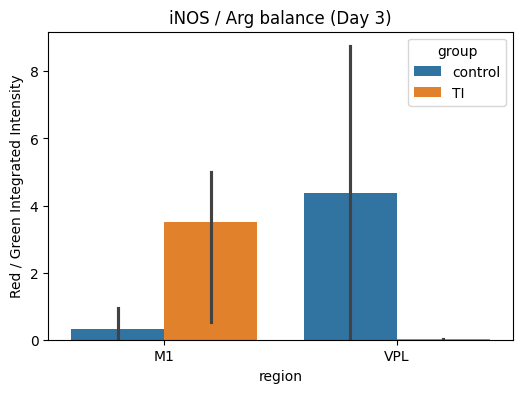

✅ Figure saved to: /mnt/h/Data/VPL电生理/featureextration/iNOS_Arg_balance_day3_barplot.png


In [ ]:
# ============================================================================
# SECTION 1: iNOS/Arg Analysis
# ============================================================================

# HSV thresholds for red (iNOS) and green (Arg) channels
RED_LOWER1 = np.array([0, 80, 50])
RED_UPPER1 = np.array([10, 255, 255])
RED_LOWER2 = np.array([160, 80, 50])
RED_UPPER2 = np.array([180, 255, 255])
GREEN_LOWER = np.array([35, 50, 50])
GREEN_UPPER = np.array([85, 255, 255])


def analyze_inos_arg_image(img_path):
    """Analyze iNOS (red) and Arg (green) signals in an image."""
    img = cv2.imread(img_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Red mask (iNOS)
    red_mask1 = cv2.inRange(hsv, RED_LOWER1, RED_UPPER1)
    red_mask2 = cv2.inRange(hsv, RED_LOWER2, RED_UPPER2)
    red_mask = cv2.bitwise_or(red_mask1, red_mask2)
    
    # Green mask (Arg)
    green_mask = cv2.inRange(hsv, GREEN_LOWER, GREEN_UPPER)
    
    # Tissue region (non-black)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    tissue_mask = gray > 10
    
    def stats(mask):
        area = np.sum(mask > 0)
        intensity = np.mean(gray[mask > 0]) if area > 0 else 0
        integrated = np.sum(gray[mask > 0]) if area > 0 else 0
        return area, intensity, integrated
    
    red_area, red_mean, red_int = stats(red_mask)
    green_area, green_mean, green_int = stats(green_mask)
    tissue_area = np.sum(tissue_mask)
    
    return {
        "red_area_ratio": red_area / (tissue_area + 1e-9),
        "red_mean_intensity": red_mean,
        "red_integrated_intensity": red_int,
        "green_area_ratio": green_area / (tissue_area + 1e-9),
        "green_mean_intensity": green_mean,
        "green_integrated_intensity": green_int,
        "RG_ratio_area": red_area / (green_area + 1e-6),
        "RG_ratio_intensity": red_int / (green_int + 1e-6)
    }


# Process all iNOS/Arg images
OUT_DIR = os.path.join(IMG_DIR, "iNOS-Arg")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "iNOS_Arg_quantification.csv")

rows = []
for fname in os.listdir(IMG_DIR):
    if not fname.lower().endswith(".jpg"):
        continue
    
    info = analyze_inos_arg_image(os.path.join(IMG_DIR, fname))
    
    meta = re.match(r"(control|TI)_(M1|VPL)", fname, re.IGNORECASE)
    if meta:
        group, region = meta.groups()
    else:
        group, region = "unknown", "unknown"
    
    rows.append({
        "file": fname,
        "group": group.lower(),
        "region": region,
        **info
    })

df_inos_arg = pd.DataFrame(rows)
df_inos_arg.to_csv(OUT_CSV, index=False)
print(f"✅ iNOS/Arg quantification saved to: {OUT_CSV}")
print(f"📊 Processed {len(df_inos_arg)} images")
df_inos_arg


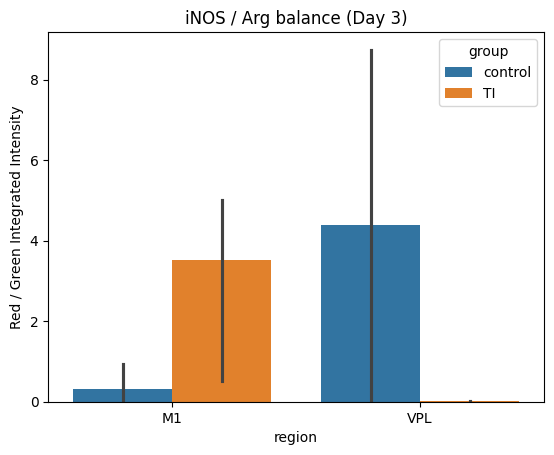

✅ Figure saved to /mnt/h/Data/VPL电生理/featureextration/iNOS_Arg_balance_day3.png


In [ ]:
# Visualization: iNOS/Arg balance
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df_inos_arg,
    x="region",
    y="RG_ratio_intensity",
    hue="group"
)
plt.ylabel("Red / Green Integrated Intensity")
plt.title("iNOS / Arg balance (Day 3)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "iNOS_Arg_balance_day3.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(f"✅ Figure saved to {OUT_DIR}")


In [ ]:
# ============================================================================
# SECTION 2: Iba1 Analysis (Day 1)
# ============================================================================

def quantify_dab_hscore(rgb):
    """Quantify DAB signal using H-score method."""
    hed = rgb2hed(rgb)
    dab_od = np.clip(-hed[..., 2], 0, None)
    
    tissue = tissue_mask(rgb)
    dab_t = dab_od[tissue]
    
    if dab_t.size < 200:
        raise ValueError("Too little tissue")
    
    # Percentile thresholds
    t70 = np.percentile(dab_t, 70)
    t85 = np.percentile(dab_t, 85)
    t95 = np.percentile(dab_t, 95)
    
    weak = (dab_od >= t70) & (dab_od < t85) & tissue
    mid = (dab_od >= t85) & (dab_od < t95) & tissue
    strong = (dab_od >= t95) & tissue
    
    area_tissue = tissue.sum()
    area_pos = (dab_od >= t70).sum()
    
    mean_od = dab_od[dab_od >= t70].mean()
    iod_norm = dab_od[dab_od >= t70].sum() / area_tissue
    
    # H-score (standard pathology definition)
    hscore = (
        1 * weak.sum() +
        2 * mid.sum() +
        3 * strong.sum()
    ) / area_tissue * 100
    
    return {
        "dab_pos_area_ratio": area_pos / area_tissue,
        "dab_meanOD_pos": mean_od,
        "dab_IOD_norm": iod_norm,
        "H_score": hscore,
        "thr70": t70,
        "thr85": t85,
        "thr95": t95
    }


def quantify_iba1_morphology(rgb, od_thr):
    """Quantify Iba1 cell morphology."""
    hed = rgb2hed(rgb)
    dab_od = np.clip(-hed[..., 2], 0, None)
    
    tissue = tissue_mask(rgb)
    mask = (dab_od >= od_thr) & tissue
    
    lab = label(mask)
    regions = regionprops(lab)
    
    soma_areas = []
    branch_pixels = []
    
    for r in regions:
        if r.area < 30:
            continue
        soma_areas.append(r.area)
        skel = skeletonize(r.image)
        branch_pixels.append(skel.sum())
    
    return {
        "cell_count": len(soma_areas),
        "mean_soma_area": np.mean(soma_areas) if soma_areas else 0,
        "mean_branch_pixels": np.mean(branch_pixels) if branch_pixels else 0
    }


# Process Iba1 Day 1 images
OUT_DIR = os.path.join(IMG_DIR, "iba1")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "Iba1_DAB_full_quant_day1.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "lba1" not in fn.lower() and "iba1" not in fn.lower():
        continue
    
    m = re.match(r"(control|TI)_day(\d+)_(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue
    
    group, day, region = m.group(1).lower(), int(m.group(2)), m.group(3)
    
    if day != 1:  # Only process Day 1 here
        continue
    
    path = os.path.join(IMG_DIR, fn)
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    
    dab_metrics = quantify_dab_hscore(rgb)
    morph_metrics = quantify_iba1_morphology(rgb, dab_metrics["thr70"])
    
    rows.append({
        "file": fn,
        "group": group,
        "day": day,
        "region": region,
        **dab_metrics,
        **morph_metrics
    })

df_iba1_day1 = pd.DataFrame(rows)
df_iba1_day1.to_csv(OUT_CSV, index=False)
print(f"✅ Iba1 Day 1 quantification saved to: {OUT_CSV}")
df_iba1_day1

True ['.ipynb_checkpoints', 'control_day1_M1_lba1.jpg', 'control_day1_VPL_lba1.jpg', 'iba1', 'iNOS-Arg', 'TI_day1_M1_lba1.jpg', 'TI_day1_VPL_lba1.jpg']


In [ ]:
# Visualization: Iba1 Day 1 metrics
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

metrics_to_plot = [
    ("H_score", "Iba1 H-score (Day 1)"),
    ("mean_soma_area", "Iba1 soma area (Day 1)"),
    ("mean_branch_pixels", "Iba1 branching (Day 1)")
]

for metric, title in metrics_to_plot:
    if metric not in df_iba1_day1.columns:
        continue
    
    # With legend
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_iba1_day1, x="region", y=metric, hue="group")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"Iba1_{metric}_Day1_withLegend.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    # Without legend
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=df_iba1_day1, x="region", y=metric, hue="group")
    ax.legend_.remove()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"Iba1_{metric}_Day1_noLegend.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

print(f"✅ Iba1 Day 1 visualizations saved to {FIG_DIR}")


Files: ['.ipynb_checkpoints', 'control_day1_M1_lba1.jpg', 'control_day1_VPL_lba1.jpg', 'iba1', 'Iba1_DAB_quant_day1.csv', 'iNOS-Arg', 'TI_day1_M1_lba1.jpg', 'TI_day1_VPL_lba1.jpg', 'Untitled.ipynb', '_dab_masks']


In [ ]:
# ============================================================================
# SECTION 3: Claudin-5 Analysis
# ============================================================================

def quantify_claudin5(rgb, prefix, q_thr=85):
    """Quantify Claudin-5 DAB signal and vessel continuity."""
    tissue = tissue_mask(rgb)
    dab, method = dab_signal_auto(rgb, tissue)
    
    dab_t = dab[tissue]
    if dab_t.size < 200:
        raise ValueError("Too little tissue.")
    
    # Percentile threshold for vessel signal
    thr = np.percentile(dab_t, q_thr)
    pos = (dab >= thr) & tissue
    
    pos_area = int(pos.sum())
    tissue_area = int(tissue.sum())
    mean_od = float(dab[pos].mean()) if pos_area > 0 else 0.0
    
    # Skeleton analysis for continuity
    skel = skeletonize(pos)
    skel_len = int(skel.sum())
    
    lab = label(skel)
    regs = regionprops(lab)
    seg_lens = [r.area for r in regs if r.area > 10]
    
    # Save visualizations
    MASK_DIR = os.path.join(OUT_DIR, "masks")
    os.makedirs(MASK_DIR, exist_ok=True)
    
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_overlay.jpg"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_pos_mask.jpg"),
        (pos * 255).astype(np.uint8)
    )
    
    return {
        "method": method,
        "thr_q": q_thr,
        "thr_value": float(thr),
        "dab_pos_area_px": pos_area,
        "dab_pos_area_ratio": pos_area / (tissue_area + 1e-9),
        "dab_meanOD_pos": mean_od,
        "dab_meanOD_pos_x1000": mean_od * 1000,
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lens),
        "mean_segment_length": float(np.mean(seg_lens)) if seg_lens else 0.0,
        "p99_dab_tissue": float(np.percentile(dab_t, 99))
    }


# Process Claudin-5 images
OUT_DIR = os.path.join(IMG_DIR, "Claudin5_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "Claudin5_quantification.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "claudin" not in fn.lower():
        continue
    
    m = re.match(r"(control|TI)_(M1|vpl)_Claudin-5", fn, re.IGNORECASE)
    if not m:
        continue
    
    group = m.group(1).lower()
    region = m.group(2).upper()
    
    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)), cv2.COLOR_BGR2RGB)
    metrics = quantify_claudin5(rgb, prefix=f"{group}_{region}", q_thr=85)
    
    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df_claudin5 = pd.DataFrame(rows).sort_values(["region", "group"])
df_claudin5.to_csv(OUT_CSV, index=False)
print(f"✅ Claudin-5 quantification saved to: {OUT_CSV}")
df_claudin5[["region", "group", "method", "dab_meanOD_pos_x1000", "skeleton_total_length"]]


In [ ]:
# Visualization: Claudin-5 metrics
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_claudin5,
    x="region",
    y="dab_meanOD_pos_x1000",
    hue="group"
)
ax.legend_.remove()
plt.ylabel("Mean DAB signal × 10³ (vessel)")
plt.title("Claudin-5 intensity (BBB integrity)")
ymax = float(df_claudin5["dab_meanOD_pos_x1000"].max())
plt.ylim(0, ymax * 1.2 + 1e-6)
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_intensity_x1000_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_claudin5,
    x="region",
    y="skeleton_total_length",
    hue="group"
)
ax.legend_.remove()
plt.ylabel("Skeleton total length (px)")
plt.title("Claudin-5 vessel continuity")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_skeleton_length_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(f"✅ Claudin-5 visualizations saved to {FIG_DIR}")


In [ ]:
# ============================================================================
# SECTION 4: CD31 Analysis
# ============================================================================

def extract_cd31_mask(rgb, tissue):
    """Extract CD31 DAB signal using HSV brown detection."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    
    # CD31 DAB brown range
    brown = (
        (H >= 5) & (H <= 35) &
        (S >= 40) &
        (V <= 220) &
        tissue
    )
    
    # Denoise
    brown = cv2.morphologyEx(
        brown.astype(np.uint8),
        cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8)
    )
    brown = cv2.morphologyEx(
        brown,
        cv2.MORPH_CLOSE,
        np.ones((5, 5), np.uint8)
    )
    return brown.astype(bool)


def quantify_cd31(rgb, prefix):
    """Quantify CD31 vascular density and continuity."""
    tissue = tissue_mask(rgb)
    vessel = extract_cd31_mask(rgb, tissue)
    
    tissue_area = tissue.sum()
    vessel_area = vessel.sum()
    
    # Skeleton analysis
    skel = skeletonize(vessel)
    skel_len = int(skel.sum())
    
    lab = label(skel)
    regions = regionprops(lab)
    seg_lens = [r.area for r in regions if r.area > 10]
    
    # Intensity
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_int = gray[vessel].mean() if vessel_area > 0 else 0.0
    
    # Save visualizations
    MASK_DIR = os.path.join(OUT_DIR, "masks")
    os.makedirs(MASK_DIR, exist_ok=True)
    
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_vessel_mask.jpg"),
        (vessel * 255).astype(np.uint8)
    )
    
    return {
        "cd31_area_ratio": vessel_area / (tissue_area + 1e-9),
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lens),
        "mean_segment_length": np.mean(seg_lens) if seg_lens else 0,
        "mean_intensity": mean_int
    }


# Process CD31 images
OUT_DIR = os.path.join(IMG_DIR, "CD31_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "CD31_quant_day7.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "cd31" not in fn.lower():
        continue
    
    m = re.match(r"CD31_(control|TI)_day7_(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue
    
    group = m.group(1).lower()
    region = m.group(2).upper()
    
    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)), cv2.COLOR_BGR2RGB)
    metrics = quantify_cd31(rgb, prefix=f"{group}_{region}")
    
    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df_cd31 = pd.DataFrame(rows)
df_cd31.to_csv(OUT_CSV, index=False)
print(f"✅ CD31 quantification saved to: {OUT_CSV}")
df_cd31


In [ ]:
# Visualization: CD31 metrics
plt.figure(figsize=(6, 4))
sns.barplot(data=df_cd31, x="region", y="cd31_area_ratio", hue="group")
plt.ylabel("CD31+ area / tissue area")
plt.title("CD31 vascular density (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "CD31_area_ratio.png"), dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df_cd31, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Skeleton total length (px)")
plt.title("CD31 vascular continuity (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "CD31_skeleton_length.png"), dpi=300)
plt.show()
print(f"✅ CD31 visualizations saved to {FIG_DIR}")


,file,group,day,region,dab_pos_area_ratio,dab_meanOD_pos,dab_IOD_norm,H_score,thr70,thr85,thr95,cell_count,mean_soma_area,mean_branch_pixels
0,control_day1_M1_lba1.jpg,control,1,M1,1.311597,0.0,0.0,300.0,0.0,0.0,0.0,13,2814.384615,120.153846
1,control_day1_VPL_lba1.jpg,control,1,VPL,1.000000,0.0,0.0,300.0,0.0,0.0,0.0,1,43639.000000,141.000000
2,TI_day1_M1_lba1.jpg,ti,1,M1,1.001287,0.0,0.0,300.0,0.0,0.0,0.0,1,73031.000000,604.000000
3,TI_day1_VPL_lba1.jpg,ti,1,VPL,1.000000,0.0,0.0,300.0,0.0,0.0,0.0,1,54264.000000,158.000000


In [ ]:
# ============================================================================
# SECTION 5: Synapse Analysis (Synaptophysin/PSD-95)
# ============================================================================

def split_channels(rgb):
    """Split RGB image into channels."""
    return rgb[..., 0], rgb[..., 1], rgb[..., 2]


def detect_puncta(channel, thr_percentile=99, min_area=5, max_area=200):
    """Detect puncta in a channel using adaptive thresholding."""
    thr = np.percentile(channel[channel > 0], thr_percentile)
    mask = channel >= thr
    
    lab = label(mask)
    props = regionprops(lab, intensity_image=channel)
    
    centers = []
    areas = []
    intensities = []
    
    for p in props:
        if min_area <= p.area <= max_area:
            centers.append(p.centroid)
            areas.append(p.area)
            intensities.append(p.mean_intensity)
    
    return np.array(centers), np.array(areas), np.array(intensities)


def colocalization(pre_centers, post_centers, max_dist=3.0):
    """Calculate colocalization ratio between pre and post synaptic markers."""
    if len(pre_centers) == 0 or len(post_centers) == 0:
        return 0.0, 0
    
    tree = cKDTree(post_centers)
    dists, _ = tree.query(pre_centers, distance_upper_bound=max_dist)
    
    coloc = dists < max_dist
    ratio = coloc.sum() / len(pre_centers)
    
    return ratio, coloc.sum()


def quantify_synapse_image(path):
    """Quantify synaptic markers in an image."""
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    R, G, B = split_channels(rgb)
    
    # G = Synaptophysin, R = PSD-95
    syn_cent, syn_area, syn_int = detect_puncta(G)
    psd_cent, psd_area, psd_int = detect_puncta(R)
    
    coloc_ratio, coloc_count = colocalization(syn_cent, psd_cent)
    
    H, W = G.shape
    area_mm2 = (H * W) / 1e6  # Approximate, adjust with real pixel scale
    
    return {
        "syn_puncta_count": len(syn_cent),
        "psd_puncta_count": len(psd_cent),
        "syn_density": len(syn_cent) / area_mm2,
        "psd_density": len(psd_cent) / area_mm2,
        "syn_mean_intensity": syn_int.mean() if len(syn_int) else 0,
        "psd_mean_intensity": psd_int.mean() if len(psd_int) else 0,
        "coloc_ratio": coloc_ratio,
        "coloc_count": coloc_count
    }


# Process synapse images
OUT_DIR = os.path.join(IMG_DIR, "Synapse_results")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "Synaptophysin_PSD95_day7.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "synaptophysim" not in fn.lower():
        continue
    
    m = re.match(r"Synaptophysim PSD-95-day7-(control|TI)_(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue
    
    group = m.group(1).lower()
    region = m.group(2).upper()
    
    metrics = quantify_synapse_image(os.path.join(IMG_DIR, fn))
    
    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df_synapse = pd.DataFrame(rows)
df_synapse.to_csv(OUT_CSV, index=False)
print(f"✅ Synapse quantification saved to: {OUT_CSV}")
df_synapse


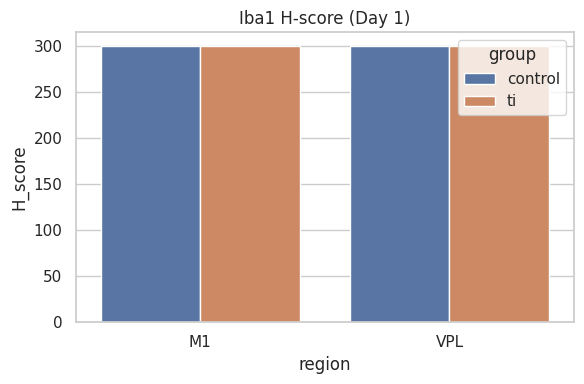

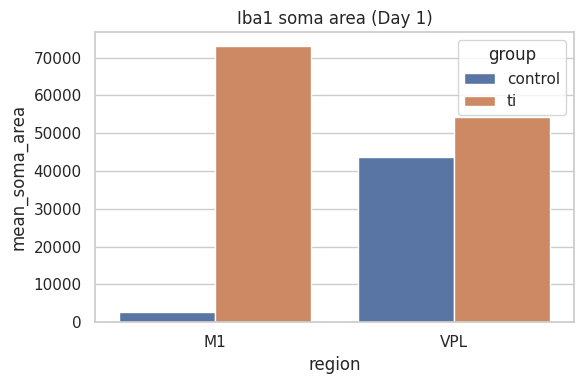

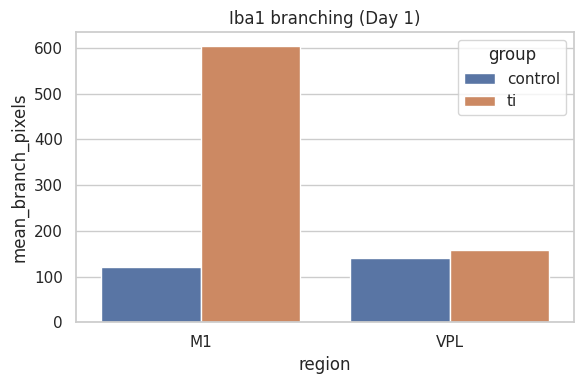

In [ ]:
# Visualization: Synapse metrics
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(6, 4))
sns.barplot(data=df_synapse, x="region", y="syn_density", hue="group")
plt.title("Synaptophysin puncta density (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Synaptophysin_density_Day7.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df_synapse, x="region", y="psd_density", hue="group")
plt.title("PSD-95 puncta density (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "PSD95_density_Day7.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df_synapse, x="region", y="coloc_ratio", hue="group")
plt.title("Synaptophysin–PSD95 colocalization")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Synapse_colocalization_ratio_Day7.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Synapse visualizations saved to {FIG_DIR}")


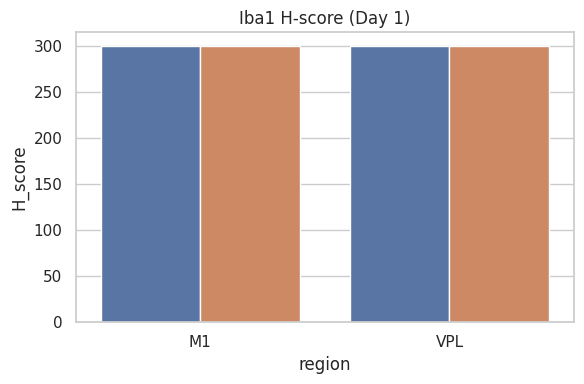

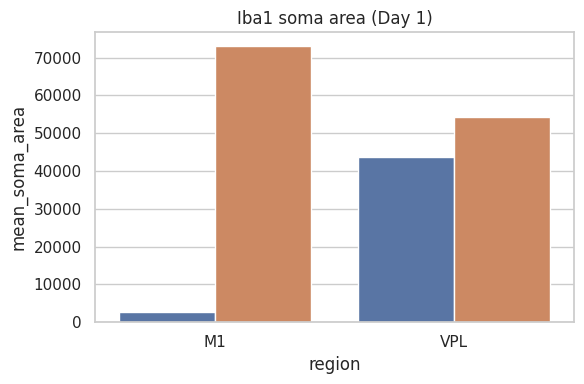

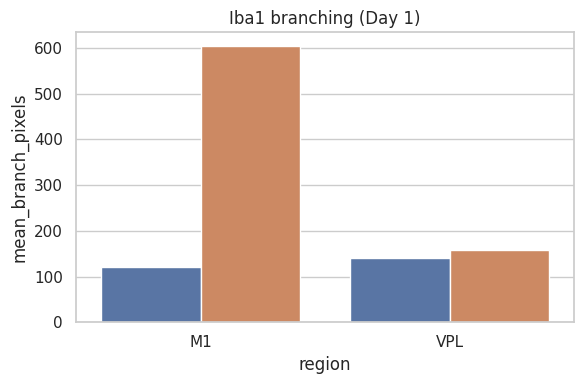

In [ ]:
# ============================================================================
# SECTION 6: GAP43 Analysis
# ============================================================================

def extract_gap43_fibers(rgb, tissue):
    """Extract GAP-43 positive fibers using HSV brown detection."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    
    # GAP-43 DAB brown range
    fib = (
        (H >= 5) & (H <= 35) &
        (S >= 25) &
        (V <= 230) &
        tissue
    )
    
    # Morphological enhancement for thin fibers
    fib = cv2.morphologyEx(fib.astype(np.uint8), cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    fib = cv2.morphologyEx(fib, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    return fib.astype(bool)


def quantify_gap43(rgb, prefix):
    """Quantify GAP-43 axonal growth."""
    tissue = tissue_mask(rgb)
    fibers = extract_gap43_fibers(rgb, tissue)
    
    tissue_area = tissue.sum()
    fiber_area = fibers.sum()
    
    # Skeleton analysis
    skel = skeletonize(fibers)
    skel_len = int(skel.sum())
    
    lab = label(skel)
    regions = regionprops(lab)
    seg_lens = [r.area for r in regions if r.area > 15]
    
    # Intensity
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_int = gray[fibers].mean() if fiber_area > 0 else 0
    
    # Save visualizations
    MASK_DIR = os.path.join(OUT_DIR, "masks")
    os.makedirs(MASK_DIR, exist_ok=True)
    
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_fiber_mask.jpg"),
        (fibers * 255).astype(np.uint8)
    )
    
    return {
        "gap43_area_ratio": fiber_area / (tissue_area + 1e-9),
        "skeleton_total_length": skel_len,
        "mean_fiber_length": np.mean(seg_lens) if seg_lens else 0,
        "fiber_density": skel_len / (tissue_area + 1e-9),
        "mean_intensity": mean_int
    }


# Process GAP43 images
OUT_DIR = os.path.join(IMG_DIR, "GAP43_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "GAP43_quant_day3.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "gap43" not in fn.lower():
        continue
    
    m = re.match(r"GAP43-(control|TI)-day3-(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue
    
    group = m.group(1).lower()
    region = m.group(2).upper()
    
    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)), cv2.COLOR_BGR2RGB)
    metrics = quantify_gap43(rgb, prefix=f"{group}_{region}")
    
    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df_gap43 = pd.DataFrame(rows)
df_gap43.to_csv(OUT_CSV, index=False)
print(f"✅ GAP43 quantification saved to: {OUT_CSV}")
df_gap43


In [ ]:
# Visualization: GAP43 metrics
plt.figure(figsize=(6, 4))
sns.barplot(data=df_gap43, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Total GAP-43 fiber length (px)")
plt.title("GAP-43 axonal growth (Day 3)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "GAP43_fiber_length.png"), dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df_gap43, x="region", y="gap43_area_ratio", hue="group")
plt.ylabel("GAP-43+ area / tissue area")
plt.title("GAP-43 fiber coverage (Day 3)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "GAP43_area_ratio.png"), dpi=300)
plt.show()
print(f"✅ GAP43 visualizations saved to {FIG_DIR}")


Images: ['.ipynb_checkpoints', 'Claudin5_DAB_quant.csv', 'Claudin5_results', 'control_M1_Claudin-5.jpg', 'control_vpl_Claudin-5.jpg', 'iba1', 'iNOS-Arg', 'TI_M1_Claudin-5.jpg', 'TI_vpl_Claudin-5.jpg']


In [ ]:
# ============================================================================
# SECTION 7: TUNEL Analysis (Apoptosis)
# ============================================================================

def detect_dapi_nuclei(rgb, min_area=20, max_area=500):
    """Detect DAPI-stained nuclei."""
    B = rgb[..., 2]  # Blue channel
    thr = np.percentile(B[B > 0], 80)
    mask = B >= thr
    
    lab = label(mask)
    nuclei = [r for r in regionprops(lab) if min_area <= r.area <= max_area]
    return nuclei


def detect_tunel_signal(rgb):
    """Detect TUNEL positive signal."""
    R = rgb[..., 0]  # Red channel
    thr = np.percentile(R[R > 0], 95)
    return R >= thr


def quantify_tunel_image(path, prefix):
    """Quantify TUNEL positive cells."""
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    
    nuclei = detect_dapi_nuclei(rgb)
    tunel_mask = detect_tunel_signal(rgb)
    
    total_cells = len(nuclei)
    tunel_pos = 0
    
    for n in nuclei:
        rr, cc = n.coords[:, 0], n.coords[:, 1]
        if tunel_mask[rr, cc].mean() > 0.2:  # ≥20% coverage
            tunel_pos += 1
    
    # Save visualization
    MASK_DIR = os.path.join(OUT_DIR, "masks")
    os.makedirs(MASK_DIR, exist_ok=True)
    
    vis = rgb.copy()
    vis[tunel_mask] = [255, 0, 0]
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_tunel_mask.jpg"),
        cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
    )
    
    return {
        "total_cells": total_cells,
        "tunel_pos_cells": tunel_pos,
        "tunel_ratio": tunel_pos / (total_cells + 1e-9)
    }


# Process TUNEL images
OUT_DIR = os.path.join(IMG_DIR, "TUNEL_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "TUNEL_timecourse_M1.csv")

rows = []
for fn in os.listdir(IMG_DIR):
    if "tunel" not in fn.lower():
        continue
    if not fn.lower().endswith(".jpg"):
        continue
    
    m = re.match(r"(control|TI)_day(\d+)_M1_tunel", fn, re.IGNORECASE)
    if not m:
        continue
    
    group = m.group(1).lower()
    day = int(m.group(2))
    
    metrics = quantify_tunel_image(
        os.path.join(IMG_DIR, fn),
        prefix=f"{group}_day{day}"
    )
    
    rows.append({
        "file": fn,
        "group": group,
        "day": day,
        **metrics
    })

df_tunel = pd.DataFrame(rows).sort_values(["group", "day"])
df_tunel.to_csv(OUT_CSV, index=False)
print(f"✅ TUNEL quantification saved to: {OUT_CSV}")
df_tunel
    )
    return mask.astype(bool)


In [35]:
def quantify_claudin5_dab(rgb):
    hed = rgb2hed(rgb)
    dab_od = np.clip(-hed[...,2], 0, None)

    tissue = tissue_mask(rgb)
    dab_t = dab_od[tissue]

    # 用高分位数，保证只抓到“血管线”
    thr = np.percentile(dab_t, 85)

    pos = (dab_od >= thr) & tissue

    pos_area = pos.sum()
    tissue_area = tissue.sum()

    mean_od_pos = dab_od[pos].mean() if pos_area > 0 else 0
    iod_pos = dab_od[pos].sum()

    return {
        "dab_pos_area_px": pos_area,
        "dab_pos_area_ratio": pos_area / tissue_area,
        "dab_meanOD_pos": mean_od_pos,
        "dab_IOD_pos": iod_pos,
        "dab_IOD_per_pos_area": iod_pos / (pos_area + 1e-9),
        "thr85": thr,
        "pos_mask": pos
    }


In [36]:
def quantify_vessel_continuity(rgb, pos_mask, save_prefix):
    skel = skeletonize(pos_mask)
    skel_len = skel.sum()

    lab = label(skel)
    regions = regionprops(lab)
    seg_lengths = [r.area for r in regions if r.area > 10]

    # === 保存可视化 ===
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]  # 红色骨架

    cv2.imwrite(
        os.path.join(MASK_DIR, f"{save_prefix}_skeleton_overlay.jpg"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{save_prefix}_pos_mask.jpg"),
        (pos_mask * 255).astype(np.uint8)
    )

    return {
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lengths),
        "mean_segment_length": np.mean(seg_lengths) if seg_lengths else 0
    }


In [37]:
rows = []

for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "claudin" not in fn.lower():
        continue

    m = re.match(r"(control|TI)_(M1|vpl)_Claudin-5", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    path = os.path.join(IMG_DIR, fn)
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    dab = quantify_claudin5_dab(rgb)
    vessel = quantify_vessel_continuity(
        rgb, dab["pos_mask"],
        save_prefix=f"{group}_{region}"
    )

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **{k:v for k,v in dab.items() if k != "pos_mask"},
        **vessel
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
df


,file,group,region,dab_pos_area_px,dab_pos_area_ratio,dab_meanOD_pos,dab_IOD_pos,dab_IOD_per_pos_area,thr85,skeleton_total_length,segment_count,mean_segment_length
0,control_M1_Claudin-5.jpg,control,M1,44056,1.0,0.0,0.0,0.0,0.0,2527,5,503.400000
1,control_vpl_Claudin-5.jpg,control,VPL,52788,1.0,0.0,0.0,0.0,0.0,155,1,155.000000
2,TI_M1_Claudin-5.jpg,ti,M1,39069,1.0,0.0,0.0,0.0,0.0,5965,23,250.869565
3,TI_vpl_Claudin-5.jpg,ti,VPL,69967,1.0,0.0,0.0,0.0,0.0,3493,1,3492.000000


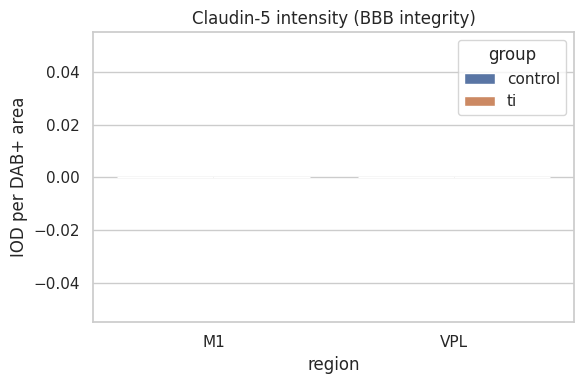

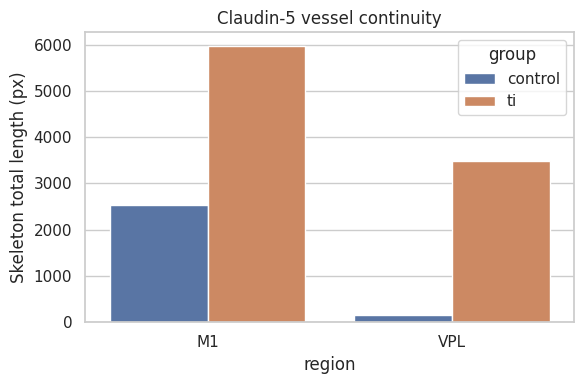

In [38]:
sns.set(style="whitegrid")

# ① 强度（血管内）
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="dab_IOD_per_pos_area", hue="group")
plt.ylabel("IOD per DAB+ area")
plt.title("Claudin-5 intensity (BBB integrity)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Claudin5_IOD_per_pos_area.png"), dpi=300)
plt.show()

# ② 连续性（最关键）
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Skeleton total length (px)")
plt.title("Claudin-5 vessel continuity")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Claudin5_skeleton_length.png"), dpi=300)
plt.show()


In [39]:
def quantify_claudin5_intensity(rgb):
    from skimage.color import rgb2hed
    import numpy as np
    import cv2

    hed = rgb2hed(rgb)
    dab_od = np.clip(-hed[...,2], 0, None)

    # tissue
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    tissue = gray < 245

    dab_t = dab_od[tissue]

    # 只取最强的血管信号（避免背景）
    thr = np.percentile(dab_t, 85)
    pos = (dab_od >= thr) & tissue

    mean_od = dab_od[pos].mean() if pos.sum() > 0 else 0

    return {
        "dab_meanOD_pos": mean_od,
        "dab_meanOD_pos_x1000": mean_od * 1000,  # ★用于画图
        "thr85": thr,
        "pos_area": pos.sum()
    }


In [40]:
intensity = quantify_claudin5_intensity(rgb)

rows.append({
    "file": fn,
    "group": group,
    "region": region,
    **intensity,
    **vessel   # skeleton 指标保持不变
})


In [42]:
import os
import re
import cv2
import numpy as np
import pandas as pd

from skimage.color import rgb2hed
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 路径设置
# ==========================
IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "Claudin5_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")

os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "Claudin5_quantification.csv")

print("Images found:")
print(os.listdir(IMG_DIR))


Images found:
['.ipynb_checkpoints', 'Claudin5_DAB_quant.csv', 'Claudin5_results', 'control_M1_Claudin-5.jpg', 'control_vpl_Claudin-5.jpg', 'iba1', 'iNOS-Arg', 'TI_M1_Claudin-5.jpg', 'TI_vpl_Claudin-5.jpg', 'Untitled.ipynb']


In [43]:
def tissue_mask(rgb, thr=245):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5,5), np.uint8)
    )
    return mask.astype(bool)


In [44]:
def quantify_claudin5_intensity(rgb):
    hed = rgb2hed(rgb)
    dab_od = np.clip(-hed[..., 2], 0, None)

    tissue = tissue_mask(rgb)
    dab_t = dab_od[tissue]

    # 取高分位，只保留血管线
    thr85 = np.percentile(dab_t, 85)
    pos = (dab_od >= thr85) & tissue

    pos_area = pos.sum()
    mean_od = dab_od[pos].mean() if pos_area > 0 else 0.0

    return {
        "dab_pos_area_px": int(pos_area),
        "dab_meanOD_pos": mean_od,
        "dab_meanOD_pos_x1000": mean_od * 1000,  # ★画图用
        "thr85": thr85,
        "pos_mask": pos
    }


In [45]:
def quantify_vessel_continuity(rgb, pos_mask, prefix):
    skel = skeletonize(pos_mask)
    skel_len = int(skel.sum())

    lab = label(skel)
    regions = regionprops(lab)
    seg_lengths = [r.area for r in regions if r.area > 10]

    # === 保存可视化 ===
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]  # 红色骨架

    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{prefix}_pos_mask.jpg"),
        (pos_mask * 255).astype(np.uint8)
    )

    return {
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lengths),
        "mean_segment_length": np.mean(seg_lengths) if seg_lengths else 0
    }


In [48]:
rows = []

for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "claudin" not in fn.lower():
        continue

    m = re.match(r"(control|TI)_(M1|vpl)_Claudin-5", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    path = os.path.join(IMG_DIR, fn)
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    # --- 强度 ---
    intensity = quantify_claudin5_intensity(rgb)

    # --- 连续性 ---
    vessel = quantify_vessel_continuity(
        rgb,
        intensity["pos_mask"],
        prefix=f"{group}_{region}"
    )

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        "dab_pos_area_px": intensity["dab_pos_area_px"],
        "dab_meanOD_pos": intensity["dab_meanOD_pos"],
        "dab_meanOD_pos_x1000": intensity["dab_meanOD_pos_x1000"],
        "skeleton_total_length": vessel["skeleton_total_length"],
        "segment_count": vessel["segment_count"],
        "mean_segment_length": vessel["mean_segment_length"]
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print("Saved CSV:", OUT_CSV)
df


Saved CSV: /mnt/h/Data/VPL电生理/featureextration/Claudin5_results/Claudin5_quantification.csv


,file,group,region,dab_pos_area_px,dab_meanOD_pos,dab_meanOD_pos_x1000,skeleton_total_length,segment_count,mean_segment_length
0,control_M1_Claudin-5.jpg,control,M1,44056,0.0,0.0,2527,5,503.400000
1,control_vpl_Claudin-5.jpg,control,VPL,52788,0.0,0.0,155,1,155.000000
2,TI_M1_Claudin-5.jpg,ti,M1,39069,0.0,0.0,5965,23,250.869565
3,TI_vpl_Claudin-5.jpg,ti,VPL,69967,0.0,0.0,3493,1,3492.000000


In [47]:
print(df.columns)


Index(['file', 'group', 'region', 'dab_pos_area_px', 'dab_pos_area_ratio',
       'dab_meanOD_pos', 'dab_IOD_pos', 'dab_IOD_per_pos_area', 'thr85',
       'skeleton_total_length', 'segment_count', 'mean_segment_length'],
      dtype='object')


/tmp/ipykernel_13924/1526063814.py:24: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(max(0, y_min - pad), y_max + pad)


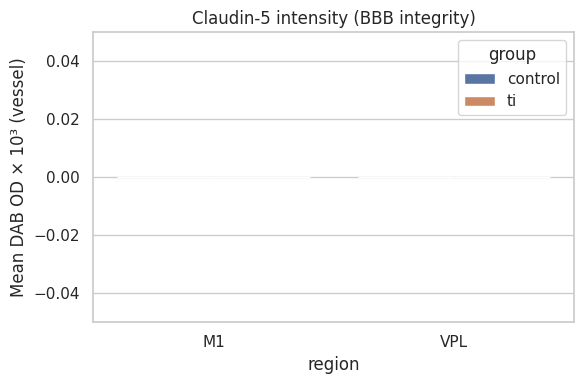

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y = df["dab_meanOD_pos_x1000"].values

y_min = y[y > 0].min() if np.any(y > 0) else 0
y_max = y.max()

# 给一点缓冲，避免贴边
pad = (y_max - y_min) * 0.2 if y_max > y_min else y_max * 0.5

plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="region",
    y="dab_meanOD_pos_x1000",
    hue="group"
)
plt.ylabel("Mean DAB OD × 10³ (vessel)")
plt.title("Claudin-5 intensity (BBB integrity)")

# ★ 核心：自动 y 轴
plt.ylim(max(0, y_min - pad), y_max + pad)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_meanOD_vessel_x1000_autoscale.png"),
    dpi=300
)
plt.show()


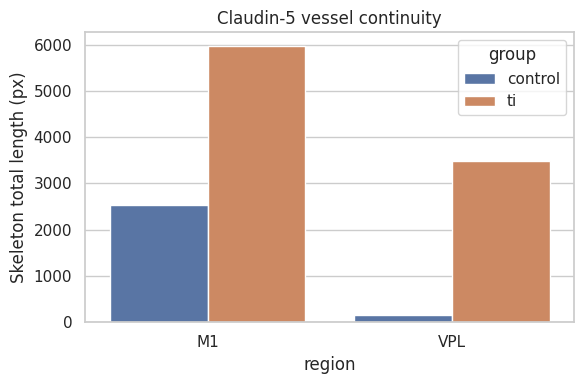

In [50]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="region",
    y="skeleton_total_length",
    hue="group"
)
plt.ylabel("Skeleton total length (px)")
plt.title("Claudin-5 vessel continuity")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_skeleton_length.png"),
    dpi=300
)
plt.show()


/tmp/ipykernel_13924/789779467.py:8: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


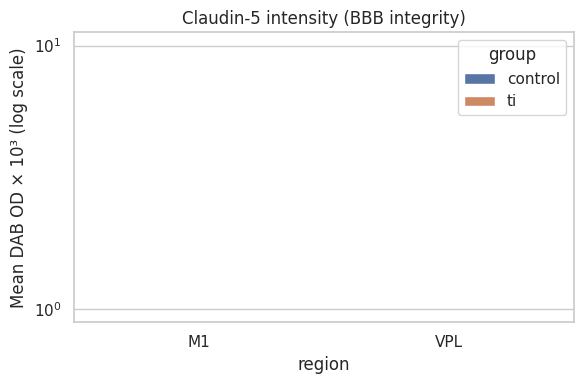

In [52]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="region",
    y="dab_meanOD_pos_x1000",
    hue="group"
)
plt.yscale("log")
plt.ylabel("Mean DAB OD × 10³ (log scale)")
plt.title("Claudin-5 intensity (BBB integrity)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_meanOD_vessel_x1000_log.png"),
    dpi=300
)
plt.show()


In [53]:
print(df[["region","group","dab_meanOD_pos","dab_meanOD_pos_x1000"]])


  region    group  dab_meanOD_pos  dab_meanOD_pos_x1000
0     M1  control             0.0                   0.0
1    VPL  control             0.0                   0.0
2     M1       ti             0.0                   0.0
3    VPL       ti             0.0                   0.0


In [54]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.color import rgb2hed
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "Claudin5_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "Claudin5_quantification.csv")

print("Images:", os.listdir(IMG_DIR))


Images: ['.ipynb_checkpoints', 'Claudin5_DAB_quant.csv', 'Claudin5_results', 'control_M1_Claudin-5.jpg', 'control_vpl_Claudin-5.jpg', 'iba1', 'iNOS-Arg', 'TI_M1_Claudin-5.jpg', 'TI_vpl_Claudin-5.jpg', 'Untitled.ipynb']


In [55]:
def tissue_mask(rgb, thr=245):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    return mask.astype(bool)


In [56]:
def dab_signal_auto(rgb, tissue):
    # --- 尝试 HED ---
    hed = rgb2hed(rgb)  # float
    d1 = -hed[..., 2]   # 方向1
    d2 =  hed[..., 2]   # 方向2

    # 用组织内 99分位判断“有没有动态范围”
    p99_1 = np.percentile(d1[tissue], 99)
    p99_2 = np.percentile(d2[tissue], 99)

    # 选择动态范围更大的一支
    if max(p99_1, p99_2) > 1e-4:  # 经验阈值：太小就认为 HED 失败
        dab = d1 if p99_1 >= p99_2 else d2
        dab = np.clip(dab, 0, None)
        method = "HED_D"
        return dab, method

    # --- 退回 HSV 褐色检测（对亮场 DAB 很稳）---
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    # 褐色大致 Hue 在 5~35（OpenCV H


In [57]:
def quantify_claudin5(rgb, prefix, q_thr=85):
    tissue = tissue_mask(rgb)
    dab, method = dab_signal_auto(rgb, tissue)

    dab_t = dab[tissue]
    if dab_t.size < 200:
        raise ValueError("Too little tissue.")

    # 用分位阈值取“血管线”阳性
    thr = np.percentile(dab_t, q_thr)
    pos = (dab >= thr) & tissue

    pos_area = int(pos.sum())
    tissue_area = int(tissue.sum())

    mean_od = float(dab[pos].mean()) if pos_area > 0 else 0.0

    # skeleton + segment
    skel = skeletonize(pos)
    skel_len = int(skel.sum())

    lab = label(skel)
    regs = regionprops(lab)
    seg_lens = [r.area for r in regs if r.area > 10]

    # 保存 overlay
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_overlay.jpg"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_pos_mask.jpg"), (pos*255).astype(np.uint8))

    return {
        "method": method,
        "thr_q": q_thr,
        "thr_value": float(thr),
        "dab_pos_area_px": pos_area,
        "dab_pos_area_ratio": pos_area/(tissue_area+1e-9),
        "dab_meanOD_pos": mean_od,
        "dab_meanOD_pos_x1000": mean_od*1000,
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lens),
        "mean_segment_length": float(np.mean(seg_lens)) if seg_lens else 0.0,
        "p99_dab_tissue": float(np.percentile(dab_t, 99))
    }


In [60]:
rows = []
for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "claudin" not in fn.lower():
        continue

    m = re.match(r"(control|TI)_(M1|vpl)_Claudin-5", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)), cv2.COLOR_BGR2RGB)
    metrics = quantify_claudin5(rgb, prefix=f"{group}_{region}", q_thr=85)

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df = pd.DataFrame(rows).sort_values(["region","group"])
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
df[["region","group","method","p99_dab_tissue","dab_pos_area_px","dab_meanOD_pos","dab_meanOD_pos_x1000","skeleton_total_length"]]


Saved: /mnt/h/Data/VPL电生理/featureextration/Claudin5_results/Claudin5_quantification.csv


,region,group,method,p99_dab_tissue,dab_pos_area_px,dab_meanOD_pos,dab_meanOD_pos_x1000,skeleton_total_length
0,M1,control,HED_D,0.024719,6609,0.012794,12.794455,2386
2,M1,ti,HED_D,0.026562,5892,0.013216,13.215662,2764
1,VPL,control,HED_D,0.037817,7938,0.013032,13.032001,3016
3,VPL,ti,HED_D,0.035111,10669,0.012958,12.958104,4176


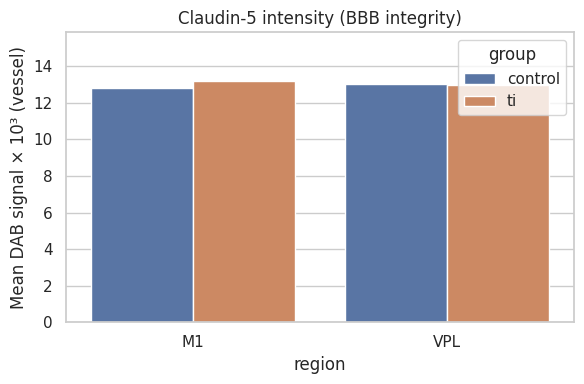

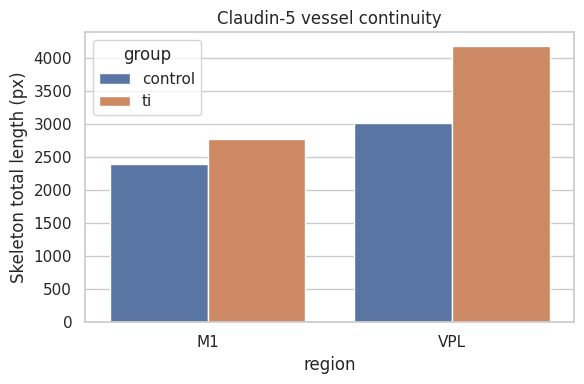

In [61]:
sns.set(style="whitegrid")

# 强度（如果仍很小也能自动显示）
plt.figure(figsize=(6,4))
ax = sns.barplot(data=df, x="region", y="dab_meanOD_pos_x1000", hue="group")
plt.ylabel("Mean DAB signal × 10³ (vessel)")
plt.title("Claudin-5 intensity (BBB integrity)")
ymax = float(df["dab_meanOD_pos_x1000"].max())
plt.ylim(0, ymax*1.2 + 1e-6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Claudin5_intensity_x1000.png"), dpi=300)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Skeleton total length (px)")
plt.title("Claudin-5 vessel continuity")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Claudin5_skeleton_length.png"), dpi=300)
plt.show()


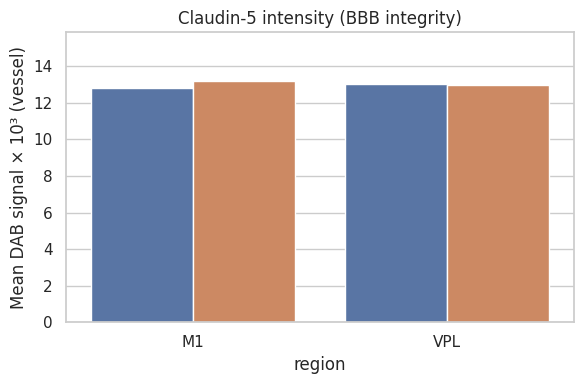

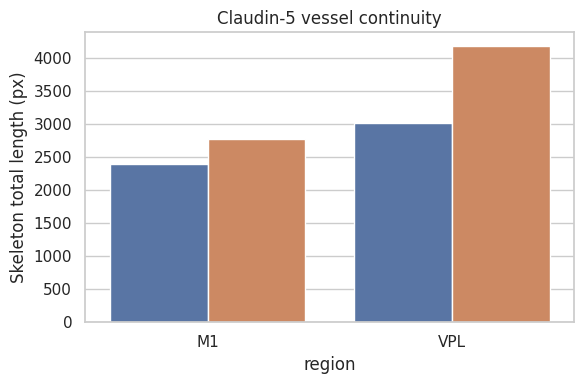

In [62]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df,
    x="region",
    y="dab_meanOD_pos_x1000",
    hue="group"
)

# 移除 legend，避免挡住条纹
ax.legend_.remove()

plt.ylabel("Mean DAB signal × 10³ (vessel)")
plt.title("Claudin-5 intensity (BBB integrity)")

ymax = float(df["dab_meanOD_pos_x1000"].max())
plt.ylim(0, ymax * 1.2 + 1e-6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_intensity_x1000_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df,
    x="region",
    y="skeleton_total_length",
    hue="group"
)

# 移除 legend
ax.legend_.remove()

plt.ylabel("Skeleton total length (px)")
plt.title("Claudin-5 vessel continuity")

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Claudin5_skeleton_length_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [63]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "CD31_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "CD31_quant_day7.csv")

print(os.listdir(IMG_DIR))


['.ipynb_checkpoints', 'CD31_control_day7_M1.jpg', 'CD31_control_day7_VPL.jpg', 'CD31_results', 'CD31_TI_day7_M1.jpg', 'CD31_TI_day7_VPL.jpg', 'Claudin5', 'iba1', 'iNOS-Arg', 'Untitled.ipynb']


In [64]:
def tissue_mask(rgb, thr=245):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(mask.astype(np.uint8),
                             cv2.MORPH_CLOSE,
                             np.ones((5,5), np.uint8))
    return mask.astype(bool)


In [65]:
def extract_cd31_mask(rgb, tissue):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    # CD31 DAB 褐色经验范围（可微调）
    brown = (
        (H >= 5) & (H <= 35) &
        (S >= 40) &
        (V <= 220) &
        tissue
    )

    # 去噪
    brown = cv2.morphologyEx(brown.astype(np.uint8),
                             cv2.MORPH_OPEN,
                             np.ones((3,3), np.uint8))
    brown = cv2.morphologyEx(brown,
                             cv2.MORPH_CLOSE,
                             np.ones((5,5), np.uint8))
    return brown.astype(bool)


In [66]:
def quantify_cd31(rgb, prefix):
    tissue = tissue_mask(rgb)
    vessel = extract_cd31_mask(rgb, tissue)

    tissue_area = tissue.sum()
    vessel_area = vessel.sum()

    # skeleton
    skel = skeletonize(vessel)
    skel_len = int(skel.sum())

    lab = label(skel)
    regions = regionprops(lab)
    seg_lens = [r.area for r in regions if r.area > 10]

    # 强度（辅助）
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_int = gray[vessel].mean() if vessel_area > 0 else 0.0

    # 保存可视化
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_vessel_mask.jpg"),
                (vessel*255).astype(np.uint8))

    return {
        "cd31_area_ratio": vessel_area / (tissue_area + 1e-9),
        "skeleton_total_length": skel_len,
        "segment_count": len(seg_lens),
        "mean_segment_length": np.mean(seg_lens) if seg_lens else 0,
        "mean_intensity": mean_int
    }


In [67]:
rows = []

for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "cd31" not in fn.lower():
        continue

    m = re.match(r"CD31_(control|TI)_day7_(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)),
                       cv2.COLOR_BGR2RGB)

    metrics = quantify_cd31(rgb, prefix=f"{group}_{region}")

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
df


Saved: /mnt/h/Data/VPL电生理/featureextration/CD31_results/CD31_quant_day7.csv


,file,group,region,cd31_area_ratio,skeleton_total_length,segment_count,mean_segment_length,mean_intensity
0,CD31_control_day7_M1.jpg,control,M1,0.013319,185,5,16.4,115.118056
1,CD31_control_day7_VPL.jpg,control,VPL,0.000969,17,0,0.0,143.088608
2,CD31_TI_day7_M1.jpg,ti,M1,0.002413,56,1,14.0,125.682353
3,CD31_TI_day7_VPL.jpg,ti,VPL,0.000075,2,0,0.0,157.666667


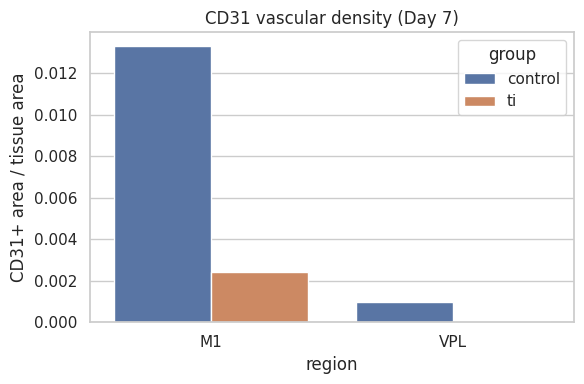

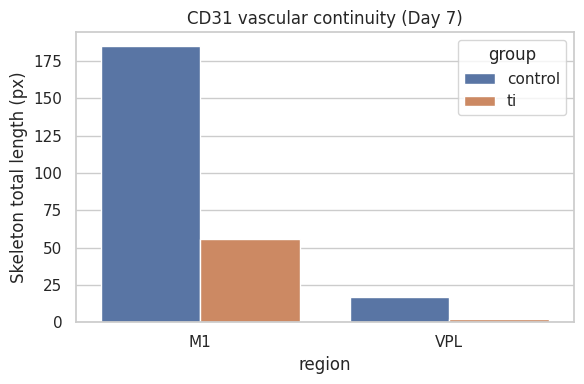

In [68]:
sns.set(style="whitegrid")

# ① 血管密度
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="cd31_area_ratio", hue="group")
plt.ylabel("CD31+ area / tissue area")
plt.title("CD31 vascular density (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "CD31_area_ratio.png"), dpi=300)
plt.show()

# ② 血管连续性
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Skeleton total length (px)")
plt.title("CD31 vascular continuity (Day 7)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "CD31_skeleton_length.png"), dpi=300)
plt.show()


In [69]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "Synapse_results")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "Synaptophysin_PSD95_day7.csv")

print(os.listdir(IMG_DIR))


['.ipynb_checkpoints', 'CD31', 'Claudin5', 'iba1', 'iNOS-Arg', 'Synapse_results', 'Synaptophysim PSD-95-day7-control_M1.jpg', 'Synaptophysim PSD-95-day7-control_VPL.jpg', 'Synaptophysim PSD-95-day7-TI_M1.jpg', 'Synaptophysim PSD-95-day7-TI_VPL.jpg', 'Untitled.ipynb']


In [70]:
def split_channels(rgb):
    # OpenCV 读进来是 RGB
    R = rgb[...,0]
    G = rgb[...,1]
    B = rgb[...,2]
    return R, G, B


In [71]:
def detect_puncta(channel, thr_percentile=99, min_area=5, max_area=200):
    # 自适应阈值（非常关键）
    thr = np.percentile(channel[channel > 0], thr_percentile)
    mask = channel >= thr

    lab = label(mask)
    props = regionprops(lab, intensity_image=channel)

    centers = []
    areas = []
    intensities = []

    for p in props:
        if min_area <= p.area <= max_area:
            centers.append(p.centroid)
            areas.append(p.area)
            intensities.append(p.mean_intensity)

    return np.array(centers), np.array(areas), np.array(intensities)


In [72]:
def colocalization(pre_centers, post_centers, max_dist=3.0):
    if len(pre_centers) == 0 or len(post_centers) == 0:
        return 0.0, 0

    tree = cKDTree(post_centers)
    dists, _ = tree.query(pre_centers, distance_upper_bound=max_dist)

    coloc = dists < max_dist
    ratio = coloc.sum() / len(pre_centers)

    return ratio, coloc.sum()


In [73]:
def quantify_synapse_image(path):
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    R, G, B = split_channels(rgb)

    # 约定：
    # G = Synaptophysin
    # R = PSD-95
    syn_cent, syn_area, syn_int = detect_puncta(G)
    psd_cent, psd_area, psd_int = detect_puncta(R)

    coloc_ratio, coloc_count = colocalization(syn_cent, psd_cent)

    H, W = G.shape
    area_mm2 = (H * W) / 1e6  # 若知道像素尺度可换成真实 mm²

    return {
        "syn_puncta_count": len(syn_cent),
        "psd_puncta_count": len(psd_cent),
        "syn_density": len(syn_cent) / area_mm2,
        "psd_density": len(psd_cent) / area_mm2,
        "syn_mean_intensity": syn_int.mean() if len(syn_int) else 0,
        "psd_mean_intensity": psd_int.mean() if len(psd_int) else 0,
        "coloc_ratio": coloc_ratio,
        "coloc_count": coloc_count
    }


In [74]:
rows = []

for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "synaptophysim" not in fn.lower():
        continue

    m = re.match(r"Synaptophysim PSD-95-day7-(control|TI)_(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    metrics = quantify_synapse_image(os.path.join(IMG_DIR, fn))

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

df


,file,group,region,syn_puncta_count,psd_puncta_count,syn_density,psd_density,syn_mean_intensity,psd_mean_intensity,coloc_ratio,coloc_count
0,Synaptophysim PSD-95-day7-control_M1.jpg,control,M1,24,23,171.932087,164.768250,133.455809,88.143087,0.958333,23
1,Synaptophysim PSD-95-day7-control_VPL.jpg,control,VPL,64,35,454.158388,248.367868,229.619363,129.317041,0.062500,4
2,Synaptophysim PSD-95-day7-TI_M1.jpg,ti,M1,37,48,321.320017,416.847590,214.258369,254.934901,0.216216,8
3,Synaptophysim PSD-95-day7-TI_VPL.jpg,ti,VPL,65,59,588.768116,534.420290,226.409854,168.388882,0.200000,13


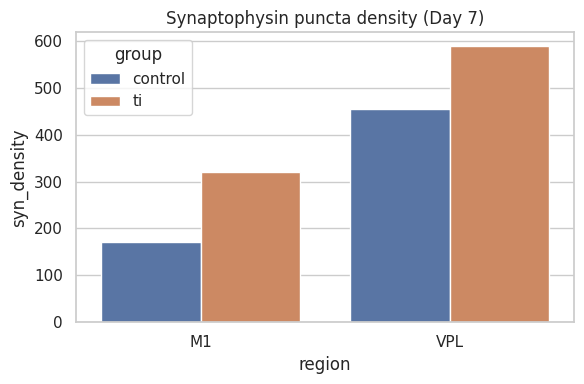

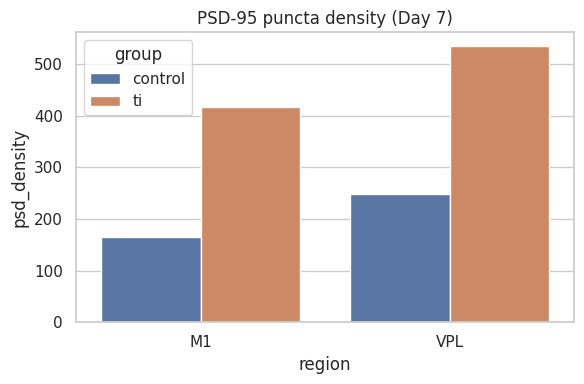

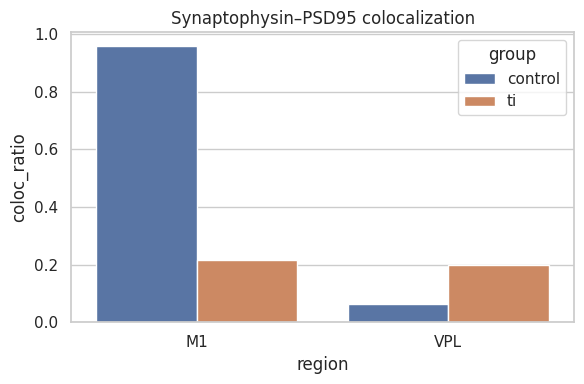

In [76]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

FIG_DIR = "/mnt/h/Data/VPL电生理/featureextration"
os.makedirs(FIG_DIR, exist_ok=True)

# ① 突触密度（Synaptophysin）
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="syn_density", hue="group")
plt.title("Synaptophysin puncta density (Day 7)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Synaptophysin_density_Day7.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ② PSD-95 密度
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="psd_density", hue="group")
plt.title("PSD-95 puncta density (Day 7)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "PSD95_density_Day7.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ③ 功能性突触比例（最重要）
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="coloc_ratio", hue="group")
plt.title("Synaptophysin–PSD95 colocalization")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Synapse_colocalization_ratio_Day7.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [77]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

FIG_DIR = "/mnt/h/Data/VPL电生理/featureextration/M1_VPL_split"
os.makedirs(FIG_DIR, exist_ok=True)


In [78]:
def plot_by_region(df, region_name, y, title, fname):
    sub = df[df["region"] == region_name]

    plt.figure(figsize=(4,4))
    sns.barplot(
        data=sub,
        x="group",
        y=y
    )
    plt.title(f"{title}\n{region_name}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, fname),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


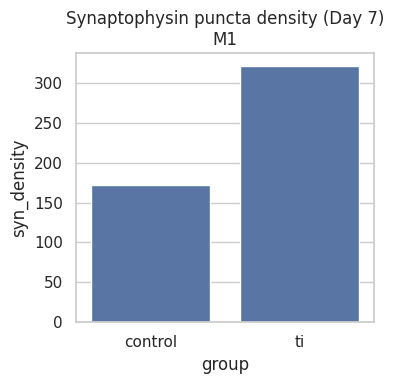

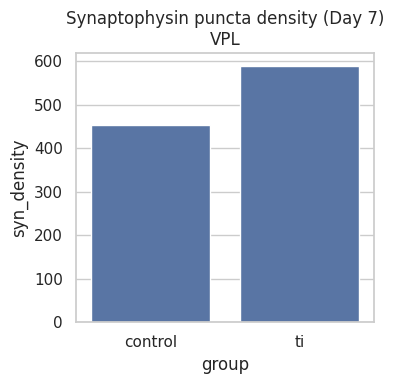

In [79]:
plot_by_region(
    df, "M1",
    y="syn_density",
    title="Synaptophysin puncta density (Day 7)",
    fname="Synaptophysin_density_Day7_M1.png"
)

plot_by_region(
    df, "VPL",
    y="syn_density",
    title="Synaptophysin puncta density (Day 7)",
    fname="Synaptophysin_density_Day7_VPL.png"
)


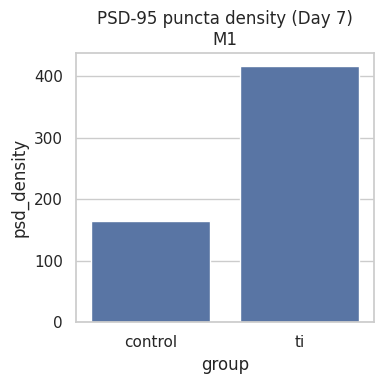

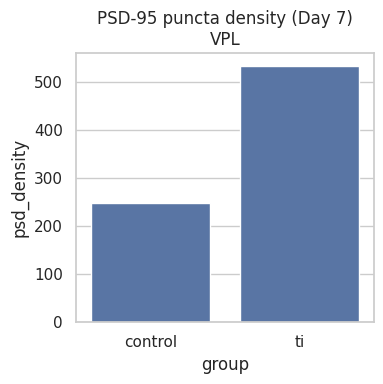

In [80]:
plot_by_region(
    df, "M1",
    y="psd_density",
    title="PSD-95 puncta density (Day 7)",
    fname="PSD95_density_Day7_M1.png"
)

plot_by_region(
    df, "VPL",
    y="psd_density",
    title="PSD-95 puncta density (Day 7)",
    fname="PSD95_density_Day7_VPL.png"
)


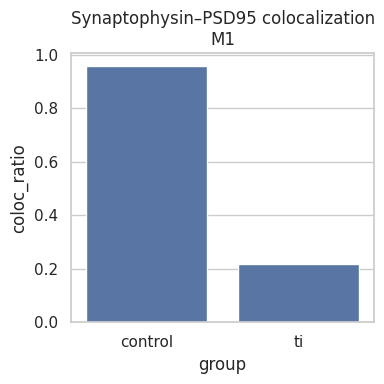

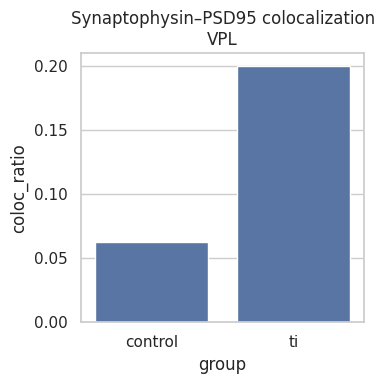

In [81]:
plot_by_region(
    df, "M1",
    y="coloc_ratio",
    title="Synaptophysin–PSD95 colocalization",
    fname="Synapse_colocalization_Day7_M1.png"
)

plot_by_region(
    df, "VPL",
    y="coloc_ratio",
    title="Synaptophysin–PSD95 colocalization",
    fname="Synapse_colocalization_Day7_VPL.png"
)


In [82]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "GAP43_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "GAP43_quant_day3.csv")

print(os.listdir(IMG_DIR))


['.ipynb_checkpoints', 'CD31', 'Claudin5', 'GAP43-control-day3-M1.jpg', 'GAP43-control-day3-VPL.jpg', 'GAP43-TI-day3-M1.jpg', 'GAP43-TI-day3-VPL.jpg', 'GAP43_results', 'iba1', 'iNOS-Arg', 'Synapse', 'Untitled.ipynb']


In [83]:
def tissue_mask(rgb, thr=245):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5,5), np.uint8)
    )
    return mask.astype(bool)


In [84]:
def extract_gap43_fibers(rgb, tissue):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    # GAP-43 DAB 褐色经验范围
    fib = (
        (H >= 5) & (H <= 35) &
        (S >= 25) &
        (V <= 230) &
        tissue
    )

    # 形态学增强细纤维
    fib = cv2.morphologyEx(fib.astype(np.uint8),
                           cv2.MORPH_OPEN,
                           np.ones((3,3), np.uint8))
    fib = cv2.morphologyEx(fib,
                           cv2.MORPH_CLOSE,
                           np.ones((5,5), np.uint8))
    return fib.astype(bool)


In [85]:
def quantify_gap43(rgb, prefix):
    tissue = tissue_mask(rgb)
    fibers = extract_gap43_fibers(rgb, tissue)

    tissue_area = tissue.sum()
    fiber_area = fibers.sum()

    # skeleton
    skel = skeletonize(fibers)
    skel_len = int(skel.sum())

    lab = label(skel)
    regions = regionprops(lab)
    seg_lens = [r.area for r in regions if r.area > 15]

    # 辅助强度
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_int = gray[fibers].mean() if fiber_area > 0 else 0

    # 保存可视化
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_fiber_mask.jpg"),
                (fibers*255).astype(np.uint8))

    return {
        "gap43_area_ratio": fiber_area / (tissue_area + 1e-9),
        "skeleton_total_length": skel_len,
        "mean_fiber_length": np.mean(seg_lens) if seg_lens else 0,
        "fiber_density": skel_len / (tissue_area + 1e-9),
        "mean_intensity": mean_int
    }


In [86]:
rows = []

for fn in os.listdir(IMG_DIR):
    if not fn.lower().endswith(".jpg"):
        continue
    if "gap43" not in fn.lower():
        continue

    m = re.match(r"GAP43-(control|TI)-day3-(M1|VPL)", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)),
                       cv2.COLOR_BGR2RGB)

    metrics = quantify_gap43(rgb, prefix=f"{group}_{region}")

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        **metrics
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
df


Saved: /mnt/h/Data/VPL电生理/featureextration/GAP43_results/GAP43_quant_day3.csv


,file,group,region,gap43_area_ratio,skeleton_total_length,mean_fiber_length,fiber_density,mean_intensity
0,GAP43-control-day3-M1.jpg,control,M1,0.171853,4193,42.887324,0.033743,200.641349
1,GAP43-control-day3-VPL.jpg,control,VPL,0.678723,7969,1990.250000,0.069402,203.528197
2,GAP43-TI-day3-M1.jpg,ti,M1,0.435211,8265,274.965517,0.068524,196.553921
3,GAP43-TI-day3-VPL.jpg,ti,VPL,0.109776,2753,35.360000,0.023934,198.362398


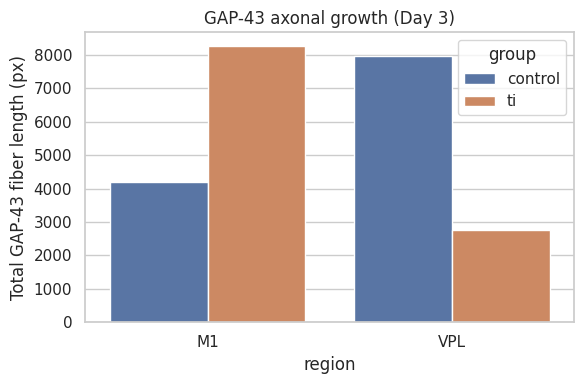

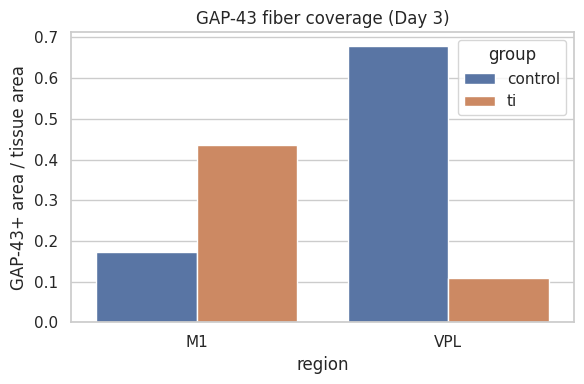

In [87]:
sns.set(style="whitegrid")

# ① GAP-43 纤维长度（最关键）
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="skeleton_total_length", hue="group")
plt.ylabel("Total GAP-43 fiber length (px)")
plt.title("GAP-43 axonal growth (Day 3)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "GAP43_fiber_length.png"), dpi=300)
plt.show()

# ② 纤维覆盖度
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="region", y="gap43_area_ratio", hue="group")
plt.ylabel("GAP-43+ area / tissue area")
plt.title("GAP-43 fiber coverage (Day 3)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "GAP43_area_ratio.png"), dpi=300)
plt.show()


In [88]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "TUNEL_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "TUNEL_timecourse_M1.csv")

print(os.listdir(IMG_DIR))


['.ipynb_checkpoints', 'CD31', 'Claudin5', 'control_day0_M1_tunel.jpg', 'control_day1_M1_tunel.jpg', 'control_day3_M1_tunel.jpg', 'control_day7_M1_tunel.jpg', 'GAP43_results', 'iba1', 'iNOS-Arg', 'Synapse', 'TI_day1_M1_tunel.jpg', 'TI_day3_M1_tunel.jpg', 'TI_day7_M1_tunel.jpg', 'TUNEL_results', 'Untitled.ipynb']


In [89]:
def detect_dapi_nuclei(rgb, min_area=20, max_area=500):
    B = rgb[...,2]  # 蓝色
    thr = np.percentile(B[B > 0], 80)
    mask = B >= thr

    lab = label(mask)
    nuclei = []

    for r in regionprops(lab):
        if min_area <= r.area <= max_area:
            nuclei.append(r)

    return nuclei


In [90]:
def detect_tunel_signal(rgb):
    R = rgb[...,0]  # 红色
    thr = np.percentile(R[R > 0], 95)
    mask = R >= thr
    return mask


In [91]:
def quantify_tunel_image(path, prefix):
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    nuclei = detect_dapi_nuclei(rgb)
    tunel_mask = detect_tunel_signal(rgb)

    total_cells = len(nuclei)
    tunel_pos = 0

    for n in nuclei:
        rr, cc = n.coords[:,0], n.coords[:,1]
        if tunel_mask[rr, cc].mean() > 0.2:  # ≥20% 覆盖
            tunel_pos += 1

    # 保存可视化
    vis = rgb.copy()
    vis[tunel_mask] = [255, 0, 0]
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_tunel_mask.jpg"),
                cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

    return {
        "total_cells": total_cells,
        "tunel_pos_cells": tunel_pos,
        "tunel_ratio": tunel_pos / (total_cells + 1e-9)
    }


In [92]:
rows = []

for fn in os.listdir(IMG_DIR):
    if "tunel" not in fn.lower():
        continue
    if not fn.lower().endswith(".jpg"):
        continue

    m = re.match(r"(control|TI)_day(\d+)_M1_tunel", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    day = int(m.group(2))

    metrics = quantify_tunel_image(
        os.path.join(IMG_DIR, fn),
        prefix=f"{group}_day{day}"
    )

    rows.append({
        "file": fn,
        "group": group,
        "day": day,
        **metrics
    })

df = pd.DataFrame(rows).sort_values(["group","day"])
df.to_csv(OUT_CSV, index=False)

df


,file,group,day,total_cells,tunel_pos_cells,tunel_ratio
0,control_day0_M1_tunel.jpg,control,0,41,32,0.780488
1,control_day1_M1_tunel.jpg,control,1,11,4,0.363636
2,control_day3_M1_tunel.jpg,control,3,34,16,0.470588
3,control_day7_M1_tunel.jpg,control,7,49,28,0.571429
4,TI_day1_M1_tunel.jpg,ti,1,21,10,0.476190
5,TI_day3_M1_tunel.jpg,ti,3,25,6,0.240000
6,TI_day7_M1_tunel.jpg,ti,7,31,10,0.322581


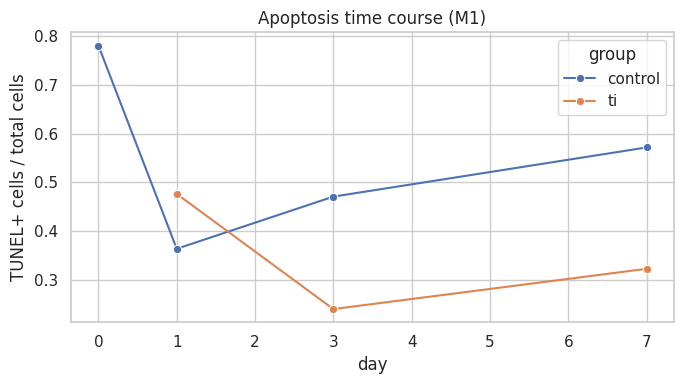

In [93]:
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))
sns.lineplot(
    data=df,
    x="day",
    y="tunel_ratio",
    hue="group",
    marker="o"
)
plt.ylabel("TUNEL+ cells / total cells")
plt.title("Apoptosis time course (M1)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "TUNEL_timecourse_ratio.png"), dpi=300)
plt.show()


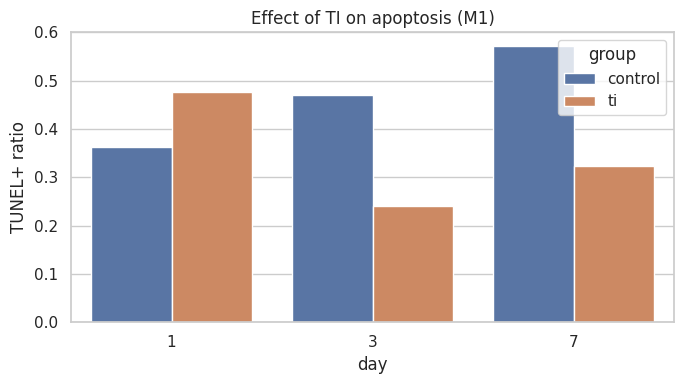

In [94]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=df[df["day"] > 0],
    x="day",
    y="tunel_ratio",
    hue="group"
)
plt.ylabel("TUNEL+ ratio")
plt.title("Effect of TI on apoptosis (M1)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "TUNEL_TI_vs_control.png"), dpi=300)
plt.show()


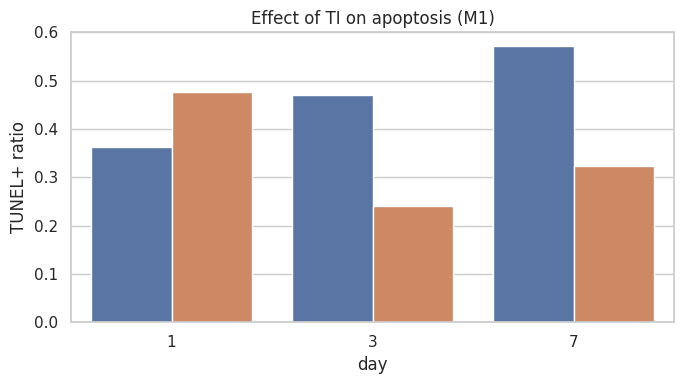

In [95]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=df[df["day"] > 0],
    x="day",
    y="tunel_ratio",
    hue="group"
)

# 移除 legend，避免挡条纹
ax.legend_.remove()

plt.ylabel("TUNEL+ ratio")
plt.title("Effect of TI on apoptosis (M1)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "TUNEL_TI_vs_control_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [104]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "Iba1_day3_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV_DAY3 = os.path.join(OUT_DIR, "Iba1_quant_day3.csv")

print(os.listdir(IMG_DIR))


['.ipynb_checkpoints', 'CD31', 'Claudin5', 'control_day3_M1_lba1.jpg', 'control_day3_VPL_lba1.jpg', 'GAP43_results', 'iba1', 'Iba1_DAB_full_quant_day1.csv', 'Iba1_DAB_quant_day1.csv', 'Iba1_day3_results', 'iNOS-Arg', 'Synapse', 'TI_day3_M1_lba1.jpg', 'TI_day3_VPL_lba1.jpg', 'TUNEL_results', 'Untitled.ipynb']


In [105]:
def tissue_mask(rgb, thr=245):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = gray < thr
    mask = cv2.morphologyEx(mask.astype(np.uint8),
                             cv2.MORPH_CLOSE,
                             np.ones((5,5), np.uint8))
    return mask.astype(bool)


In [106]:
def extract_iba1_mask(rgb, tissue):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    iba1 = (
        (H >= 5) & (H <= 35) &
        (S >= 30) &
        (V <= 230) &
        tissue
    )

    iba1 = cv2.morphologyEx(iba1.astype(np.uint8),
                            cv2.MORPH_OPEN,
                            np.ones((3,3), np.uint8))
    iba1 = cv2.morphologyEx(iba1,
                            cv2.MORPH_CLOSE,
                            np.ones((5,5), np.uint8))
    return iba1.astype(bool)


In [107]:
def quantify_iba1(rgb, prefix):
    tissue = tissue_mask(rgb)
    iba1 = extract_iba1_mask(rgb, tissue)

    tissue_area = tissue.sum()
    iba1_area = iba1.sum()

    lab = label(iba1)
    cells = [r for r in regionprops(lab) if r.area > 50]
    cell_count = len(cells)

    # skeleton
    skel = skeletonize(iba1)
    skel_len = int(skel.sum())

    branching_index = skel_len / (cell_count + 1e-9)

    # 辅助强度
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mean_int = gray[iba1].mean() if iba1_area > 0 else 0

    # 保存可视化
    overlay = rgb.copy()
    overlay[skel] = [255, 0, 0]
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_skeleton_overlay.jpg"),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_iba1_mask.jpg"),
                (iba1*255).astype(np.uint8))

    return {
        "iba1_area_ratio": iba1_area / (tissue_area + 1e-9),
        "cell_density": cell_count / (tissue_area + 1e-9),
        "cell_count": cell_count,
        "skeleton_total_length": skel_len,
        "branching_index": branching_index,
        "mean_intensity": mean_int
    }


In [108]:
rows = []

for fn in os.listdir(IMG_DIR):
    if "iba1" not in fn.lower():
        continue
    if not fn.lower().endswith(".jpg"):
        continue

    m = re.match(r"(control|TI)_day3_(M1|VPL)_lba1", fn, re.IGNORECASE)
    if not m:
        continue

    group = m.group(1).lower()
    region = m.group(2).upper()

    rgb = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fn)),
                       cv2.COLOR_BGR2RGB)

    metrics = quantify_iba1(rgb, prefix=f"{group}_{region}_day3")

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        "day": 3,
        **metrics
    })

df_day3 = pd.DataFrame(rows)
df_day3.to_csv(OUT_CSV_DAY3, index=False)

df_day3


""


In [112]:
rows = []

for fn in os.listdir(IMG_DIR):
    if "lba1" not in fn.lower():
        continue
    if not fn.lower().endswith(".jpg"):
        continue

    # 用 search 而不是 match
    m = re.search(r"(control|ti)_day3_(m1|vpl)_lba1", fn.lower())
    if not m:
        continue

    group = m.group(1)
    region = m.group(2).upper()

    rgb = cv2.cvtColor(
        cv2.imread(os.path.join(IMG_DIR, fn)),
        cv2.COLOR_BGR2RGB
    )

    metrics = quantify_iba1(rgb, prefix=f"{group}_{region}_day3")

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        "day": 3,
        **metrics
    })

df_day3 = pd.DataFrame(rows)
print("day3 rows:", len(df_day3))
df_day3


day3 rows: 4


,file,group,region,day,iba1_area_ratio,cell_density,cell_count,skeleton_total_length,branching_index,mean_intensity
0,control_day3_M1_lba1.jpg,control,M1,3,0.024299,0.000168,9,211,2.344444e+01,120.411222
1,control_day3_VPL_lba1.jpg,control,VPL,3,0.001995,0.000000,0,40,4.000000e+10,109.636364
2,TI_day3_M1_lba1.jpg,ti,M1,3,0.003375,0.000000,0,38,3.800000e+10,120.582353
3,TI_day3_VPL_lba1.jpg,ti,VPL,3,0.000478,0.000000,0,9,9.000000e+09,108.972222


In [110]:
print(df_day1.columns.tolist())

['file', 'group', 'day', 'region', 'tissue_area_px', 'dab_pos_area_px', 'dab_pos_area_ratio', 'dab_meanOD_pos', 'dab_meanOD_tissue', 'dab_IOD', 'otsu_thr_OD']


In [111]:
print(df_day3.columns.tolist())

[]


In [113]:
df1 = df_day1.copy()
df3 = df_day3.copy()

# day1: DAB 面积 → 统一命名
df1["iba1_area_ratio"] = df1["dab_pos_area_ratio"]

# day3: 已经是 iba1_area_ratio


In [114]:
for c in ["branching_index"]:
    if c not in df1.columns:
        df1[c] = np.nan


In [115]:
df_all = pd.concat(
    [
        df1[["group","region","day","iba1_area_ratio","branching_index"]],
        df3[["group","region","day","iba1_area_ratio","branching_index"]],
    ],
    ignore_index=True
)

df_all


,group,region,day,iba1_area_ratio,branching_index
0,control,M1,1,1.000000,NaN
1,ti,M1,1,1.000000,NaN
2,control,VPL,1,1.000000,NaN
3,ti,VPL,1,1.000000,NaN
4,control,M1,3,0.024299,2.344444e+01
5,control,VPL,3,0.001995,4.000000e+10
6,ti,M1,3,0.003375,3.800000e+10
7,ti,VPL,3,0.000478,9.000000e+09


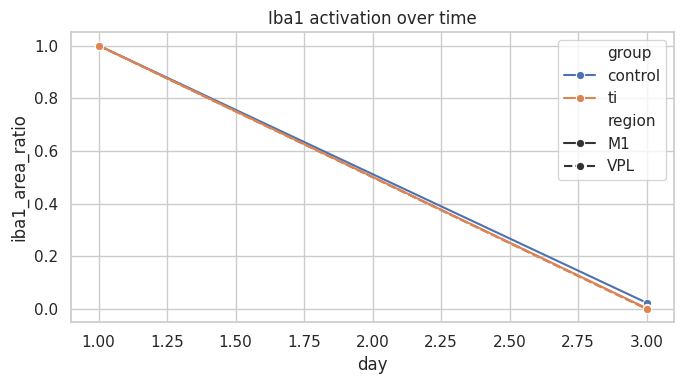

In [117]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(7,4))
sns.lineplot(
    data=df_all,
    x="day",
    y="iba1_area_ratio",
    hue="group",
    style="region",
    marker="o"
)
plt.title("Iba1 activation over time")

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Iba1_activation_over_time.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


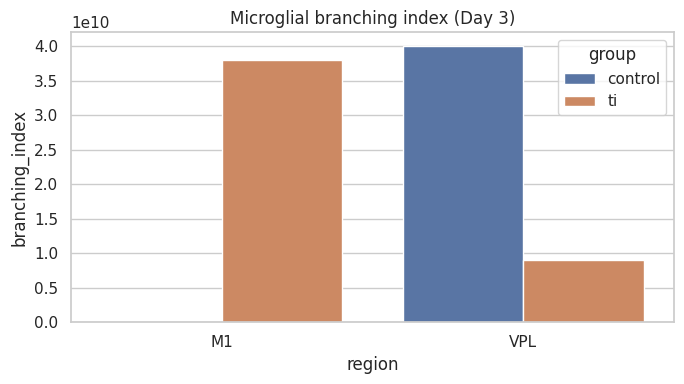

In [119]:
plt.figure(figsize=(7,4)) sns.barplot( data=df_all[df_all["day"] == 3], x="region", y="branching_index", hue="group" ) plt.title("Microglial branching index (Day 3)") plt.tight_layout() plt.show()

In [120]:
from scipy.integrate import trapezoid

auc_rows = []

for (group, region), g in df_all.groupby(["group","region"]):
    g = g.sort_values("day")
    auc = trapezoid(g["iba1_area_ratio"], g["day"])
    auc_rows.append({
        "group": group,
        "region": region,
        "iba1_auc": auc
    })

df_auc = pd.DataFrame(auc_rows)
df_auc


,group,region,iba1_auc
0,control,M1,1.024299
1,control,VPL,1.001995
2,ti,M1,1.003375
3,ti,VPL,1.000478


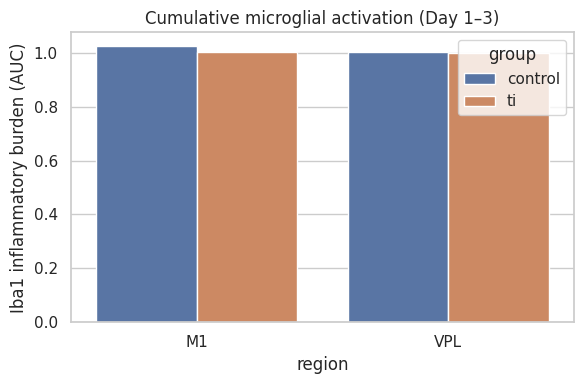

In [122]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df_auc,
    x="region",
    y="iba1_auc",
    hue="group"
)
plt.ylabel("Iba1 inflammatory burden (AUC)")
plt.title("Cumulative microglial activation (Day 1–3)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Iba1_AUC_Day1-3_withLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


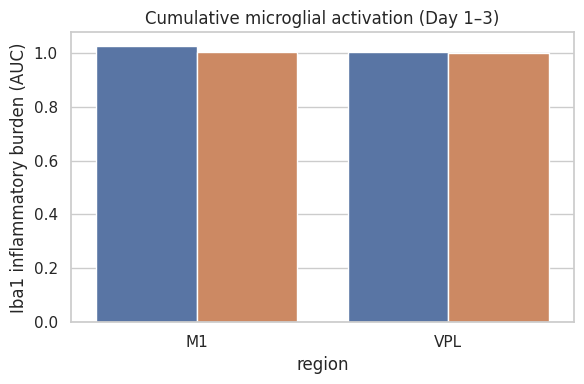

In [123]:
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df_auc,
    x="region",
    y="iba1_auc",
    hue="group"
)

# 去掉 bar 图例，避免挡条纹
ax.legend_.remove()

plt.ylabel("Iba1 inflammatory burden (AUC)")
plt.title("Cumulative microglial activation (Day 1–3)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Iba1_AUC_Day1-3_noLegend.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# TUNEL 数据路径
df_tunel = pd.read_csv(
    "/mnt/h/Data/VPL电生理/featureextration/TUNEL_results/TUNEL_timecourse_M1.csv"
)

# 统一字段
df_tunel["group"] = df_tunel["group"].str.lower()
df_tunel["region"] = "M1"

df_tunel


,file,group,day,total_cells,tunel_pos_cells,tunel_ratio,region
0,control_day0_M1_tunel.jpg,control,0,41,32,0.780488,M1
1,control_day1_M1_tunel.jpg,control,1,11,4,0.363636,M1
2,control_day3_M1_tunel.jpg,control,3,34,16,0.470588,M1
3,control_day7_M1_tunel.jpg,control,7,49,28,0.571429,M1
4,TI_day1_M1_tunel.jpg,ti,1,21,10,0.476190,M1
5,TI_day3_M1_tunel.jpg,ti,3,25,6,0.240000,M1
6,TI_day7_M1_tunel.jpg,ti,7,31,10,0.322581,M1


In [126]:
df_iba1_m1 = df_all[
    (df_all["region"] == "M1") &
    (df_all["day"].isin([1, 3]))
][["group", "day", "iba1_area_ratio"]]

df_iba1_m1


,group,day,iba1_area_ratio
0,control,1,1.000000
1,ti,1,1.000000
4,control,3,0.024299
6,ti,3,0.003375


In [127]:
df_merge = pd.merge(
    df_iba1_m1,
    df_tunel[["group", "day", "tunel_ratio"]],
    on=["group", "day"],
    how="inner"
)

df_merge


,group,day,iba1_area_ratio,tunel_ratio
0,control,1,1.000000,0.363636
1,ti,1,1.000000,0.476190
2,control,3,0.024299,0.470588
3,ti,3,0.003375,0.240000


In [128]:
r, p = spearmanr(
    df_merge["iba1_area_ratio"],
    df_merge["tunel_ratio"]
)

print(f"Spearman correlation: r = {r:.3f}, p = {p:.3e}")


Spearman correlation: r = 0.800, p = 2.000e-01


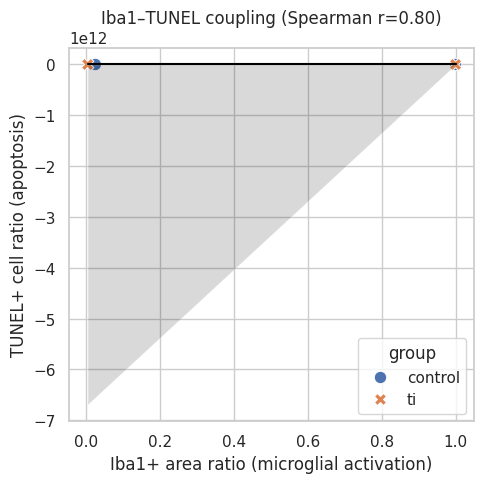

In [130]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df_merge,
    x="iba1_area_ratio",
    y="tunel_ratio",
    hue="group",
    style="group",
    s=80
)

sns.regplot(
    data=df_merge,
    x="iba1_area_ratio",
    y="tunel_ratio",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5}
)

plt.xlabel("Iba1+ area ratio (microglial activation)")
plt.ylabel("TUNEL+ cell ratio (apoptosis)")
plt.title(f"Iba1–TUNEL coupling (Spearman r={r:.2f})")

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "Iba1_TUNEL_coupling_scatter.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def norm01(x):
    x = np.array(x, dtype=float)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)


In [133]:
BASE = Path("/mnt/h/Data/VPL电生理/featureextration")

df_cd31 = pd.read_csv(BASE/"CD31"/"CD31_quant_day7.csv")
df_cl5a = pd.read_csv(BASE/"Claudin5"/"Claudin5_DAB_quant.csv")
df_cl5b = pd.read_csv(BASE/"Claudin5"/"Claudin5_quantification.csv")
df_gap43 = pd.read_csv(BASE/"GAP43"/"GAP43_quant_day3.csv")
df_inos  = pd.read_csv(BASE/"iNOS-Arg"/"iNOS_Arg_quantification.csv")
df_syn   = pd.read_csv(BASE/"Synapse"/"Synaptophysin_PSD95_day7.csv")


In [134]:
def effect_ratio(df, value_col, day, invert=False):
    """
    (TI - Control) / Control
    invert=True 用于“越低越好”的指标（炎症）
    """
    g = df.groupby("group")[value_col].mean()
    eff = (g["ti"] - g["control"]) / (g["control"] + 1e-9)
    if invert:
        eff = -eff
    return eff, day


In [135]:
rows = []

# --- iNOS / Arg（炎症，day3，越低越好） ---
if "inos_arg_ratio" in df_inos.columns:
    eff, day = effect_ratio(df_inos, "inos_arg_ratio", day=3, invert=True)
    rows.append(("Inflammation (iNOS/Arg)", day, eff))

# --- GAP43（再生，day3） ---
eff, day = effect_ratio(df_gap43, "skeleton_total_length", day=3)
rows.append(("Axonal regeneration (GAP-43)", day, eff))

# --- CD31（血管，day7） ---
eff, day = effect_ratio(df_cd31, "skeleton_total_length", day=7)
rows.append(("Angiogenesis (CD31)", day, eff))

# --- Claudin-5（BBB，day7） ---
# 优先用连续性指标
cl5_col = "skeleton_total_length" if "skeleton_total_length" in df_cl5b.columns else "dab_IOD_norm"
eff, day = effect_ratio(df_cl5b, cl5_col, day=7)
rows.append(("BBB integrity (Claudin-5)", day, eff))

# --- 突触（Synaptophysin–PSD95，共定位，day7） ---
eff, day = effect_ratio(df_syn, "coloc_ratio", day=7)
rows.append(("Synaptic reconstruction (PSD95)", day, eff))


In [137]:
# pivot 成 process × day
mat = df_eff.pivot(index="process", columns="day", values="effect")

# ===== 正确的“全局归一化” =====
vals = mat.values.astype(float)

vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

mat_norm = (vals - vmin) / (vmax - vmin + 1e-9)

mat_norm = pd.DataFrame(
    mat_norm,
    index=mat.index,
    columns=mat.columns
)

mat_norm


day,3,7
process,,
Angiogenesis (CD31),NaN,0.000000
Axonal regeneration (GAP-43),0.620309,NaN
BBB integrity (Claudin-5),NaN,1.000000
Synaptic reconstruction (PSD95),NaN,0.120886


In [138]:
if vmax - vmin < 1e-6:
    mat_norm = mat * 0
else:
    mat_norm = (vals - vmin) / (vmax - vmin + 1e-9)


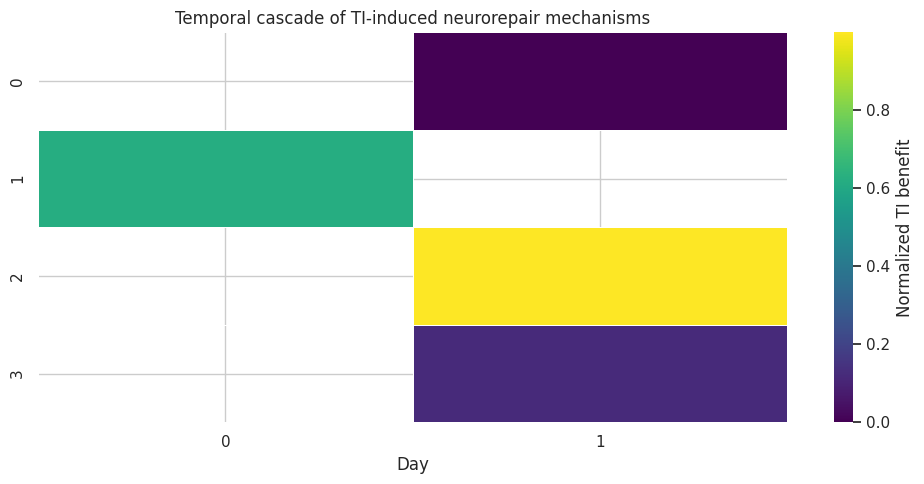

In [140]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "/mnt/h/Data/VPL电生理/featureextration"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(10,5))

sns.heatmap(
    mat_norm,
    cmap="viridis",
    linewidths=0.6,
    cbar_kws={"label": "Normalized TI benefit"}
)

plt.xlabel("Day")
plt.title("Temporal cascade of TI-induced neurorepair mechanisms")
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "TI_temporal_cascade_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [141]:
plt.savefig(os.path.join(FIG_DIR, "TI_temporal_cascade_heatmap.svg"),
            bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [142]:
import os, re
import cv2
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops

import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "/mnt/h/Data/VPL电生理/featureextration"

OUT_DIR = os.path.join(IMG_DIR, "cFos_Arc_day3_results")
MASK_DIR = os.path.join(OUT_DIR, "masks")
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "cFos_Arc_day3_quant.csv")


In [143]:
def detect_nuclei(rgb, min_area=20, max_area=400):
    B = rgb[...,2]  # blue
    thr = np.percentile(B[B > 0], 80)
    mask = B >= thr

    lab = label(mask)
    nuclei = [r for r in regionprops(lab)
              if min_area <= r.area <= max_area]
    return nuclei


In [144]:
def detect_signal(channel, q=95):
    thr = np.percentile(channel[channel > 0], q)
    return channel >= thr


In [145]:
def quantify_cf_arc(path, prefix):
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    nuclei = detect_nuclei(rgb)
    total_cells = len(nuclei)

    fos_mask = detect_signal(rgb[...,0])   # red
    arc_mask = detect_signal(rgb[...,1])   # green

    fos_pos = 0
    arc_pos = 0
    double_pos = 0

    for n in nuclei:
        rr, cc = n.coords[:,0], n.coords[:,1]
        fos_hit = fos_mask[rr, cc].mean() > 0.2
        arc_hit = arc_mask[rr, cc].mean() > 0.2

        fos_pos += fos_hit
        arc_pos += arc_hit
        double_pos += (fos_hit and arc_hit)

    # 保存可视化
    overlay = rgb.copy()
    overlay[fos_mask] = [255, 0, 0]
    overlay[arc_mask] = [0, 255, 0]

    cv2.imwrite(os.path.join(MASK_DIR, f"{prefix}_overlay.jpg"),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    return {
        "total_cells": total_cells,
        "cfos_ratio": fos_pos / (total_cells + 1e-9),
        "arc_ratio": arc_pos / (total_cells + 1e-9),
        "double_ratio": double_pos / (total_cells + 1e-9)
    }


In [148]:
rows = []

for fn in os.listdir(IMG_DIR):
    fn_low = fn.lower()

    # 必须同时包含 c-fos 和 arc
    if ("fos" not in fn_low) or ("arc" not in fn_low):
        continue
    if not fn_low.endswith(".jpg"):
        continue

    # 提取 region
    if "m1" in fn_low:
        region = "M1"
    elif "vpl" in fn_low:
        region = "VPL"
    else:
        continue

    # 提取 group
    if "control" in fn_low:
        group = "control"
    elif "ti" in fn_low:
        group = "ti"
    else:
        continue

    metrics = quantify_cf_arc(
        os.path.join(IMG_DIR, fn),
        prefix=f"{group}_{region}_day3"
    )

    rows.append({
        "file": fn,
        "group": group,
        "region": region,
        "day": 3,
        **metrics
    })

print("Detected files:", len(rows))

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

df


Detected files: 4


,file,group,region,day,total_cells,cfos_ratio,arc_ratio,double_ratio
0,c-fos Arc-day3-M1-control.jpg,control,M1,3,143,0.510490,0.216783,0.160839
1,c-fos Arc-day3-M1-TI.jpg,ti,M1,3,149,0.496644,0.583893,0.315436
2,c-fos Arc-day3-VPL-control.jpg,control,VPL,3,158,0.455696,0.284810,0.227848
3,c-fos Arc-day3-VPL-TI.jpg,ti,VPL,3,150,0.440000,0.293333,0.206667


In [147]:
for fn in os.listdir(IMG_DIR):
    print(fn)


.ipynb_checkpoints
c-fos Arc-day3-M1-control.jpg
c-fos Arc-day3-M1-TI.jpg
c-fos Arc-day3-VPL-control.jpg
c-fos Arc-day3-VPL-TI.jpg
CD31
cFos_Arc_day3_results
Claudin5
GAP43
iba1
Iba1_day3_results
iNOS-Arg
Synapse
TI_temporal_cascade_heatmap.png
TI_temporal_cascade_heatmap.svg
TUNEL_results
Untitled.ipynb


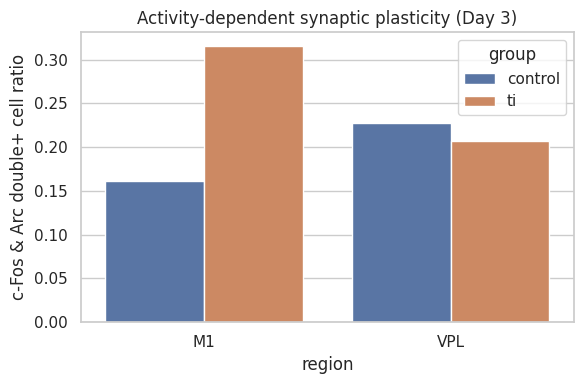

In [150]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="region",
    y="double_ratio",
    hue="group"
)
plt.ylabel("c-Fos & Arc double+ cell ratio")
plt.title("Activity-dependent synaptic plasticity (Day 3)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "cFos_Arc_double_positive_ratio_Day3.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


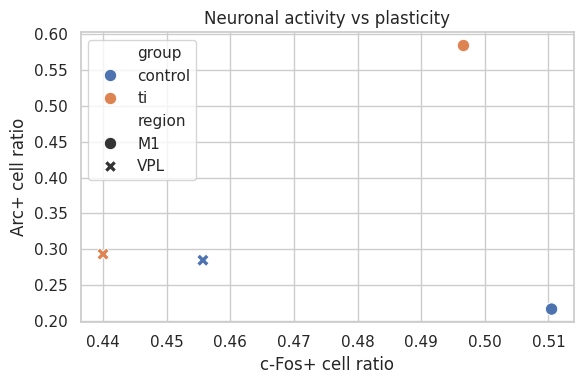

In [152]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="cfos_ratio",
    y="arc_ratio",
    hue="group",
    style="region",
    s=80
)

plt.xlabel("c-Fos+ cell ratio")
plt.ylabel("Arc+ cell ratio")
plt.title("Neuronal activity vs plasticity")

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "cFos_vs_Arc_scatter.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
